# Estimación de emisiones de CO y NOx en una turbina de gas

## Primer entregable: selección de datos, EDA y modelos base

Se estudian **36.733 registros operativos agregados por hora**, procedentes de una única turbina en Turquía entre 2011 y 2015. La tarea es estimar dos concentraciones contemporáneas, **CO y NOx (mg/m³)**, a partir de nueve mediciones ambientales y operativas. No se trata de pronosticar emisiones mediante rezagos ni de entrenar redes neuronales.

El estudio comprende la caracterización de la calidad de los datos, el análisis de asociaciones y cambios temporales, la evaluación de modelos de referencia y la revisión de antecedentes científicos. La estimación de incertidumbre, el diagnóstico de residuos y las curvas de aprendizaje complementan la evaluación predictiva.

**Protocolo principal:** bloques de 168 registros consecutivos, sin cruzar años, con una reserva cercana al 20% para prueba y cinco pliegues de validación en el desarrollo. Se excluyen del entrenamiento los vecinos a una distancia de hasta 24 registros de la prueba o la validación correspondiente. Los cinco años están representados en ambos conjuntos. La selección utiliza únicamente el MSE de validación; el modelo final se conserva para uso posterior. El diseño evalúa estimación contemporánea en condiciones representadas, no extrapolación a años futuros. El conjunto y sus particiones han sido examinados previamente: la prueba histórica no constituye evidencia prospectiva intacta.

## 1. Pregunta y objetivos

> ¿En qué medida las condiciones ambientales y las mediciones de operación permiten estimar CO y NOx en bloques operativos reservados de la misma turbina, y cómo varía el desempeño entre las condiciones representadas en 2011–2015?

**Objetivo general:** establecer una referencia reproducible para un sistema de monitoreo predictivo de emisiones (PEMS).

**Objetivos específicos:** caracterizar calidad y distribuciones; examinar relaciones y redundancia; documentar disponibilidad de sensores; evaluar media de entrenamiento, SVR lineal y Ridge mediante validación por bloques; seleccionar, guardar y evaluar un modelo final en bloques de prueba reservados; cuantificar incertidumbre y dependencia de residuos; delimitar una contribución original no neuronal frente a antecedentes publicados.

Las asociaciones no son causales. Estimar concentraciones no equivale a demostrar reducción de emisiones ni cumplimiento normativo. El umbral R² ≤ 0,70 usado en la selección es un criterio del proyecto, no un criterio universal de calidad científica.

## 2. Datos y métodos

**Fuente:** [UCI, conjunto 551](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set), DOI [10.24432/C5WC95](https://doi.org/10.24432/C5WC95). Licencia **CC BY 4.0**. Estudio original: Kaya, Tüfekci y Uzun (2019), [doi:10.3906/elk-1807-87](https://doi.org/10.3906/elk-1807-87).

**Unidad:** un registro operativo con sensores agregados durante una hora. Hay nueve predictores y dos respuestas; el año se obtiene del nombre de archivo, no es predictor. Se dispone de **una entidad industrial**, no de 36.733 turbinas independientes. La relación total n/p es 36.733/9 ≈ 4.081, pero la dependencia entre registros reduce la información efectiva.

**Estructura:** datos longitudinales de una turbina, no una muestra transversal independiente. Los archivos están ordenados cronológicamente, pero **no contienen fecha/hora exactas**. No es posible verificar huecos horarios, zona horaria o ciclos de calendario. La regresión utiliza sensores contemporáneos; la partición conserva bloques consecutivos, pero mezcla periodos y no impone una dirección temporal de entrenamiento hacia prueba. No hay coordenadas, por lo que las secciones espaciales no aplican.

**Desarrollo y prueba:** se forman bloques de **168 posiciones consecutivas**, conservando los bloques finales incompletos dentro de cada año. Se reserva aleatoriamente el 20% de los bloques, estratificando por año con semilla 42: **7.411 registros de prueba (20,18%)**. Tras excluir los **1.752 registros vecinos** a la prueba, quedan **27.570 registros de desarrollo (75,06%)**. El margen excluido representa el 4,77% y no se utiliza en el ajuste final. La proporción de filas de prueba no es exactamente 20% porque los bloques son indivisibles.

La validación distribuye los bloques de desarrollo en **cinco pliegues**, barajándolos dentro de cada año. Se aplica nuevamente el margen de 24 registros alrededor de la validación de cada pliegue. No se elimina información por valores extremos ni se utiliza la respuesta para asignar bloques. El escalado de sensores y respuesta se ajusta solo con el entrenamiento correspondiente. El año sirve para balancear las particiones y no es predictor. Las longitudes se expresan en registros, no en días de calendario verificados; el margen reduce la proximidad inmediata, pero no garantiza independencia entre bloques.

**Justificación frente a Leave-One-Year-Out (LOYO):** excluir un año completo evalúa transferencia hacia un periodo no representado. La heterogeneidad observada, en particular los menores niveles de NOx en 2014–2015, hace que ese diseño mida una dificultad distinta de la pregunta principal: estimar emisiones contemporáneas dentro de las condiciones operativas presentes en el conjunto. Por ello, LOYO no es la validación principal para este objetivo, aunque sería pertinente si se exigiera generalización hacia años desconocidos. Las diferencias de distribución no invalidan LOYO ni justifican elegir una partición únicamente para elevar R². El diseño por bloques mezcla años para representar la población de interés y evita separar individualmente observaciones próximas. No acredita capacidad predictiva en años futuros.

In [1]:
from pathlib import Path
import sys, json, warnings, importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import LinearSVR
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, silhouette_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.exceptions import ConvergenceWarning
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
import joblib

SEMILLA = 42
np.random.seed(SEMILLA)
plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
PREDICTORES = ['AT','AP','AH','AFDP','GTEP','TIT','TAT','TEY','CDP']
OBJETIVOS = ['CO','NOX']
candidatos = [Path.cwd(), Path.cwd() / 'Gas Turbine Project', Path.cwd().parent]
RAIZ = next((p for p in candidatos if (p / 'data' / 'gt_2011.csv').exists()), None)
if RAIZ is None:
    raise FileNotFoundError('Ubique el notebook junto a la carpeta data con los cinco CSV originales de UCI.')
SALIDA = RAIZ / 'informe_resultados' / 'validacion_bloques_168_purga_24'
SALIDA.mkdir(parents=True,exist_ok=True)
datos = pd.concat([pd.read_csv(RAIZ / 'data' / f'gt_{a}.csv').assign(anio=a) for a in range(2011,2016)], ignore_index=True)
datos['orden_registro'] = np.arange(len(datos))
sys.path.insert(0,str(RAIZ))
from block_model import particiones as crear_particiones
train_idx,test_idx,splits_bloques,asignacion_bloques,conteos_folds = crear_particiones(datos,168,24)
desarrollo = datos.iloc[train_idx].copy()
evaluacion = datos.iloc[test_idx].copy()
desarrollo['bloque'] = asignacion_bloques.iloc[train_idx].bloque.to_numpy()
evaluacion['bloque'] = asignacion_bloques.iloc[test_idx].bloque.to_numpy()
df = desarrollo.copy()
assert (len(desarrollo),len(evaluacion)) == (27570,7411)
assert not set(desarrollo.bloque) & set(evaluacion.bloque)
assert set(desarrollo.anio) == set(evaluacion.anio) == set(range(2011,2016))
assert len(datos)-len(desarrollo)-len(evaluacion) == 1752
versiones = {p: metadata.version(p) for p in ['numpy','pandas','scipy','scikit-learn','matplotlib','statsmodels']}
display(pd.Series(versiones, name='version'))
(SALIDA / 'versiones.json').write_text(json.dumps(versiones,indent=2),encoding='utf-8')
particiones=pd.DataFrame({'particion':['desarrollo elegible','prueba por bloques','margen excluido'],
                         'anios':['2011-2015']*3, 'filas':[len(df),len(evaluacion),1752]})
particiones['porcentaje']=100*particiones.filas/len(datos)
display(particiones.round(2))
particiones.to_csv(SALIDA/'particion_desarrollo_prueba.csv',index=False)
display(asignacion_bloques.groupby(['anio','particion']).size().unstack(fill_value=0))
print('Relación n/p en desarrollo:', round(len(df)/len(PREDICTORES),1))

numpy            2.5.3
pandas           3.0.6
scipy           1.18.1
scikit-learn     1.9.1
matplotlib      3.11.2
statsmodels     0.15.0
Name: version, dtype: str

,particion,anios,filas,porcentaje
0,desarrollo elegible,2011-2015,27570,75.06
1,prueba por bloques,2011-2015,7411,20.18
2,margen excluido,2011-2015,1752,4.77


particion,entrenamiento_CV,prueba_bloques,purga_prueba
anio,,,
2011,5640,1363,408
2012,5732,1512,384
2013,5376,1512,264
2014,5334,1512,312
2015,5488,1512,384


Relación n/p en desarrollo: 3063.3


### 2.1 Representación gráfica de las particiones

Las figuras representan la **asignación real** del protocolo, común a CO y NOx. El panel A conserva el orden de los registros dentro de cada archivo anual y distingue desarrollo, prueba y exclusión próxima a prueba. D, P y E indican sus respectivos tamaños. Los bloques finales de un año pueden tener menos de 168 registros.

El panel B muestra los cinco pliegues: cada bloque de desarrollo actúa como validación en un único pliegue. A y V indican los registros de ajuste y validación; E CV cuenta las exclusiones adicionales junto a esa validación. La prueba y su margen permanecen fuera de los cinco ajustes. La concatenación de años sirve únicamente como coordenada gráfica, no implica continuidad entre años ni una división prospectiva.

El panel C amplía dos bloques reales de 2013, uno de prueba y otro de validación, con 24 posiciones excluidas a cada lado. Los márgenes impiden utilizar vecinos inmediatos durante el ajuste, sin modificar los registros reservados para evaluación. Se expresan en posiciones, no en horas de calendario verificadas. La persistencia observada justifica precauciones de separación, pero **24 no es un umbral óptimo demostrado ni garantiza independencia**. En la vista global los márgenes son estrechos; el detalle permite reconocer su extensión.

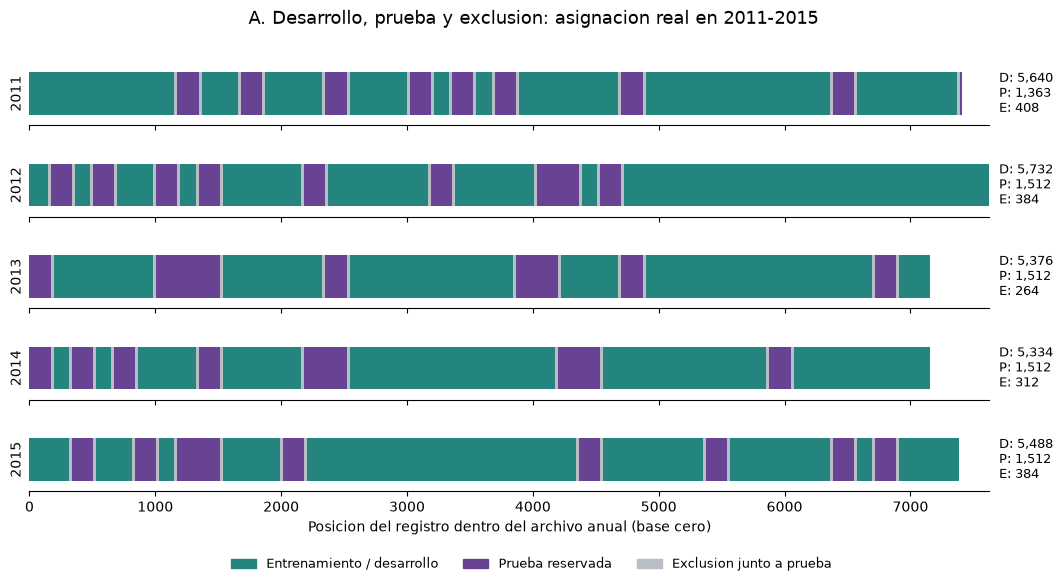

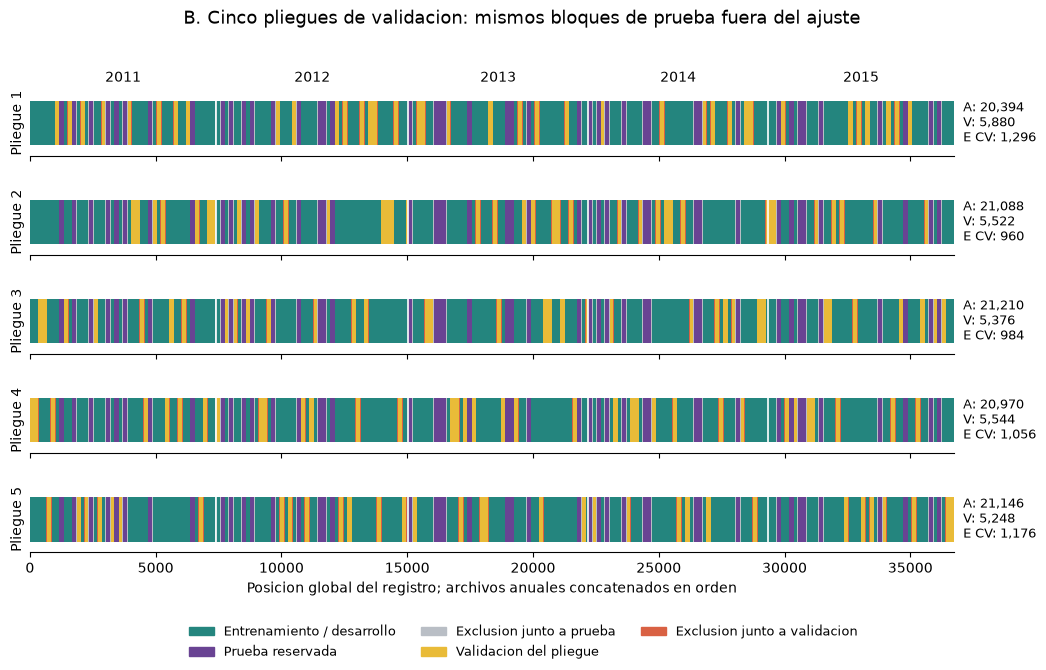

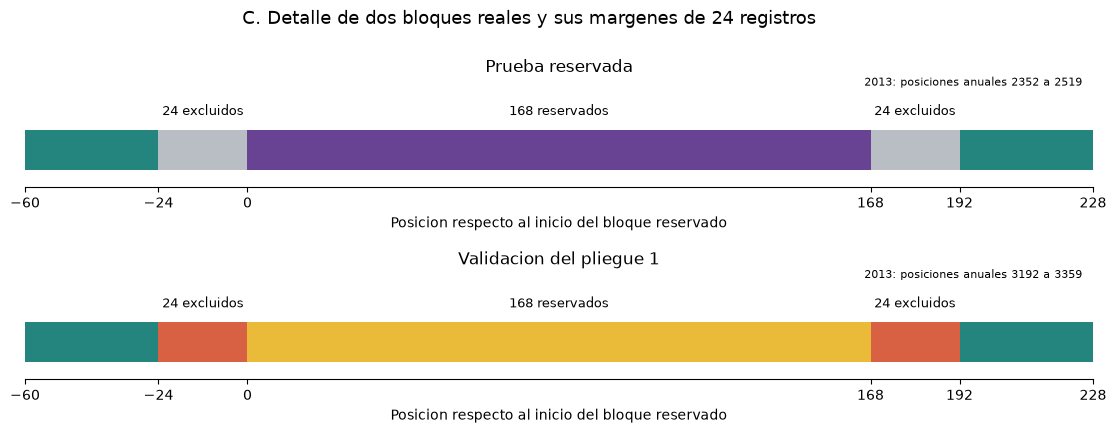

,fold,Ajuste,Validacion,Exclusion adicional CV
0,1,20394,5880,1296
1,2,21088,5522,960
2,3,21210,5376,984
3,4,20970,5544,1056
4,5,21146,5248,1176


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
vg_raices=[Path.cwd(),Path.cwd()/'Gas Turbine Project',Path.cwd().parent]
vg_raiz=next(p for p in vg_raices if (p/'data'/'gt_2011.csv').exists())
sys.path.insert(0,str(vg_raiz))
from block_model import particiones as vg_particionar
from plot_validation_design import mostrar_particiones
vg_datos=pd.concat([pd.read_csv(vg_raiz/'data'/f'gt_{a}.csv').assign(anio=a)
                    for a in range(2011,2016)],ignore_index=True)
vg_datos['orden_registro']=np.arange(len(vg_datos))
vg_tr,vg_te,vg_splits,vg_asignacion,vg_conteos=vg_particionar(vg_datos,168,24)
assert (len(vg_tr),len(vg_te))==(27570,7411)
assert sum(len(va) for _,va in vg_splits)==len(vg_tr)
mostrar_particiones(vg_datos,vg_tr,vg_te,vg_splits,vg_asignacion,vg_conteos)
display(vg_conteos.rename(columns={'n_train':'Ajuste','n_val':'Validacion',
                                 'n_purgados_CV':'Exclusion adicional CV'}))

### Diccionario operativo de variables

La predicción se realiza **después de recibir las agregaciones de sensores de la hora**, sin consultar el analizador de gases de esa hora. Por tanto, las nueve entradas deben estar disponibles e independientes del cálculo de CO/NOx. No se afirma que este conjunto permita anticipar emisiones antes de operar la turbina.

In [3]:
diccionario = pd.DataFrame([
 ('AT','Predictor continuo','°C','Temperatura ambiente'),
 ('AP','Predictor continuo','mbar','Presión ambiente'),
 ('AH','Predictor continuo','%','Humedad ambiente'),
 ('AFDP','Predictor continuo','mbar','Diferencia de presión del filtro de aire'),
 ('GTEP','Predictor continuo','mbar','Presión de escape de la turbina'),
 ('TIT','Predictor continuo','°C','Temperatura de entrada de la turbina'),
 ('TAT','Predictor continuo','°C','Temperatura después de la turbina'),
 ('TEY','Predictor continuo','MWh','Rendimiento energético registrado'),
 ('CDP','Predictor continuo','mbar','Presión de descarga del compresor'),
 ('CO','Objetivo continuo','mg/m³','Concentración de monóxido de carbono'),
 ('NOX','Objetivo continuo','mg/m³','Concentración de óxidos de nitrógeno'),
 ('anio','Control de partición','año','Extraído del archivo; excluido del modelo'),
 ('orden_registro','Control de orden','registro','Posición original; no es fecha ni predictor')
], columns=['variable','papel','unidad','significado'])
display(diccionario)

,variable,papel,unidad,significado
0,AT,Predictor continuo,°C,Temperatura ambiente
1,AP,Predictor continuo,mbar,Presión ambiente
2,AH,Predictor continuo,%,Humedad ambiente
3,AFDP,Predictor continuo,mbar,Diferencia de presión del filtro de aire
4,GTEP,Predictor continuo,mbar,Presión de escape de la turbina
5,TIT,Predictor continuo,°C,Temperatura de entrada de la turbina
6,TAT,Predictor continuo,°C,Temperatura después de la turbina
7,TEY,Predictor continuo,MWh,Rendimiento energético registrado
8,CDP,Predictor continuo,mbar,Presión de descarga del compresor
9,CO,Objetivo continuo,mg/m³,Concentración de monóxido de carbono


## 3. Resultados exploratorios

Las secciones 3.1–3.5 caracterizan las observaciones elegibles de desarrollo de los cinco años. Las secciones 3.6 y 3.7 describen retrospectivamente los 36.733 registros originales de 2011–2015, preservando sus secuencias anuales completas. Estas caracterizaciones no seleccionan sensores ni hiperparámetros. Las observaciones de prueba se mantienen excluidas del ajuste y de la búsqueda, aunque la inspección histórica del conjunto limita su carácter confirmatorio.

### 3.1 Completitud, duplicación y coherencia

La calidad de los datos elegibles de desarrollo, procedentes de 2011–2015, se evalúa mediante completitud, duplicación y coherencia física de las mediciones. La matriz de faltantes representa registros en las columnas y variables en las filas; el color blanco identifica mediciones disponibles. La ausencia de valores faltantes elimina la necesidad de imputación en esta muestra, pero no permite caracterizar posibles mecanismos de pérdida de información en otras condiciones operativas.

Se distingue una fila completamente repetida de una configuración de sensores repetida. La segunda puede corresponder a un estado operativo habitual y no implica un error. La comparación tras redondear a dos decimales busca coincidencias aproximadas, pero depende de la precisión de cada sensor. Ninguno de estos controles elimina registros automáticamente.

,tipo,faltantes,distintos,minimo,maximo
AT,float64,0,18349,-6.234800,37.1030
AP,float64,0,776,985.850000,1036.6000
AH,float64,0,20912,24.085000,100.2000
AFDP,float64,0,17386,2.087400,7.6106
GTEP,float64,0,11640,17.698000,40.7160
TIT,float64,0,772,1002.900000,1100.9000
TAT,float64,0,2623,511.040000,550.6100
TEY,float64,0,5830,100.020000,179.5000
CDP,float64,0,4283,9.851800,15.1590
CO,float64,0,20846,0.000388,44.1030


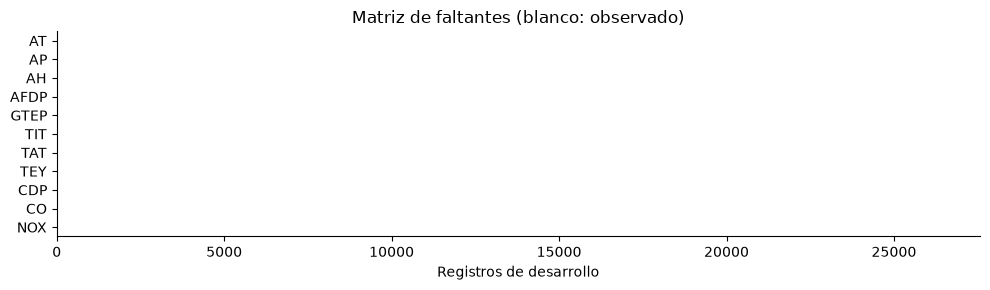

duplicados exactos                                           3
filas en configuraciones repetidas                           4
filas con entradas iguales tras redondear a 2 decimales      4
AH mayor que 100%                                          360
AH negativa                                                  0
emisiones negativas                                          0
presiones no positivas                                       0
Name: conteo, dtype: int64

Desarrollo contiene **27,570 registros** y **0 celdas faltantes**. Se detectan **3 duplicados exactos** y **4 filas** en coincidencias redondeadas. El redondeo es una aproximación exploratoria, no una prueba de duplicación.

In [4]:
columnas = PREDICTORES + OBJETIVOS
calidad = pd.DataFrame({'tipo':df[columnas].dtypes.astype(str), 'faltantes':df[columnas].isna().sum(),
                       'distintos':df[columnas].nunique(), 'minimo':df[columnas].min(), 'maximo':df[columnas].max()})
display(calidad)
fig, ax = plt.subplots(figsize=(10,3))
ax.imshow(df[columnas].isna().to_numpy().T, aspect='auto', cmap='Greys', vmin=0,vmax=1)
ax.set(yticks=np.arange(len(columnas)), yticklabels=columnas, xlabel='Registros de desarrollo', title='Matriz de faltantes (blanco: observado)')
plt.tight_layout(); plt.show()
dup = int(df.duplicated(columnas).sum())
config_rep = int(df.duplicated(PREDICTORES,keep=False).sum())
redondeados = df[PREDICTORES].round(2)
casi = int(redondeados.duplicated(keep=False).sum())
controles = {'duplicados exactos':dup, 'filas en configuraciones repetidas':config_rep,
            'filas con entradas iguales tras redondear a 2 decimales':casi,
            'AH mayor que 100%':int((df.AH>100).sum()), 'AH negativa':int((df.AH<0).sum()),
            'emisiones negativas':int((df[OBJETIVOS]<0).any(axis=1).sum()),
            'presiones no positivas':int((df[['AP','AFDP','GTEP','CDP']]<=0).any(axis=1).sum())}
display(pd.Series(controles,name='conteo'))
display(Markdown(f'Desarrollo contiene **{len(df):,} registros** y **{int(df[columnas].isna().sum().sum())} celdas faltantes**. '
                 f'Se detectan **{dup} duplicados exactos** y **{casi} filas** en coincidencias redondeadas. '
                 'El redondeo es una aproximación exploratoria, no una prueba de duplicación.'))

Las mediciones de humedad ligeramente superiores al 100% se señalan para revisión de calibración, no se corrigen sin información del sensor. Las temperaturas ambiente negativas pueden ser físicamente válidas. No se conocen identificadores de mantenimiento, operador o régimen de control. El muestreo de una sola instalación limita la representatividad para otras turbinas y otros combustibles.

### 3.2 Perfil univariado y valores extremos

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max,asimetria,curtosis_exceso
AT,27570.0,18.106,7.267,-6.235,2.675,12.580,18.392,23.824,29.349,32.016,37.103,-0.141,-0.705
AP,27570.0,1012.967,6.503,985.850,997.174,1008.900,1012.600,1016.700,1024.100,1029.900,1036.600,0.152,0.644
AH,27570.0,77.504,14.570,24.085,40.071,67.741,80.041,89.122,97.232,100.080,100.200,-0.611,-0.290
AFDP,27570.0,3.938,0.771,2.087,2.426,3.395,3.956,4.386,5.292,6.008,7.611,0.320,0.243
GTEP,27570.0,25.679,4.211,17.698,18.523,23.252,25.170,29.554,32.790,34.406,40.716,0.276,-0.722
TIT,27570.0,1082.137,17.409,1002.900,1035.700,1072.600,1086.800,1099.500,1100.100,1100.300,1100.900,-0.909,-0.075
TAT,27570.0,546.101,6.758,511.040,525.794,544.243,549.870,550.040,550.290,550.410,550.610,-1.689,1.768
TEY,27570.0,133.888,15.648,100.020,104.150,124.842,133.750,145.940,160.826,166.190,179.500,0.054,-0.575
CDP,27570.0,12.095,1.094,9.852,10.196,11.478,11.987,13.056,13.968,14.272,15.159,0.167,-0.723
CO,27570.0,2.321,2.167,0.000,0.206,1.176,1.693,2.746,5.851,10.553,44.103,4.933,52.960


C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWa

C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWa

C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
C:\Users\Work\AppData\Local\Temp\ipykernel_35724\473595762.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})


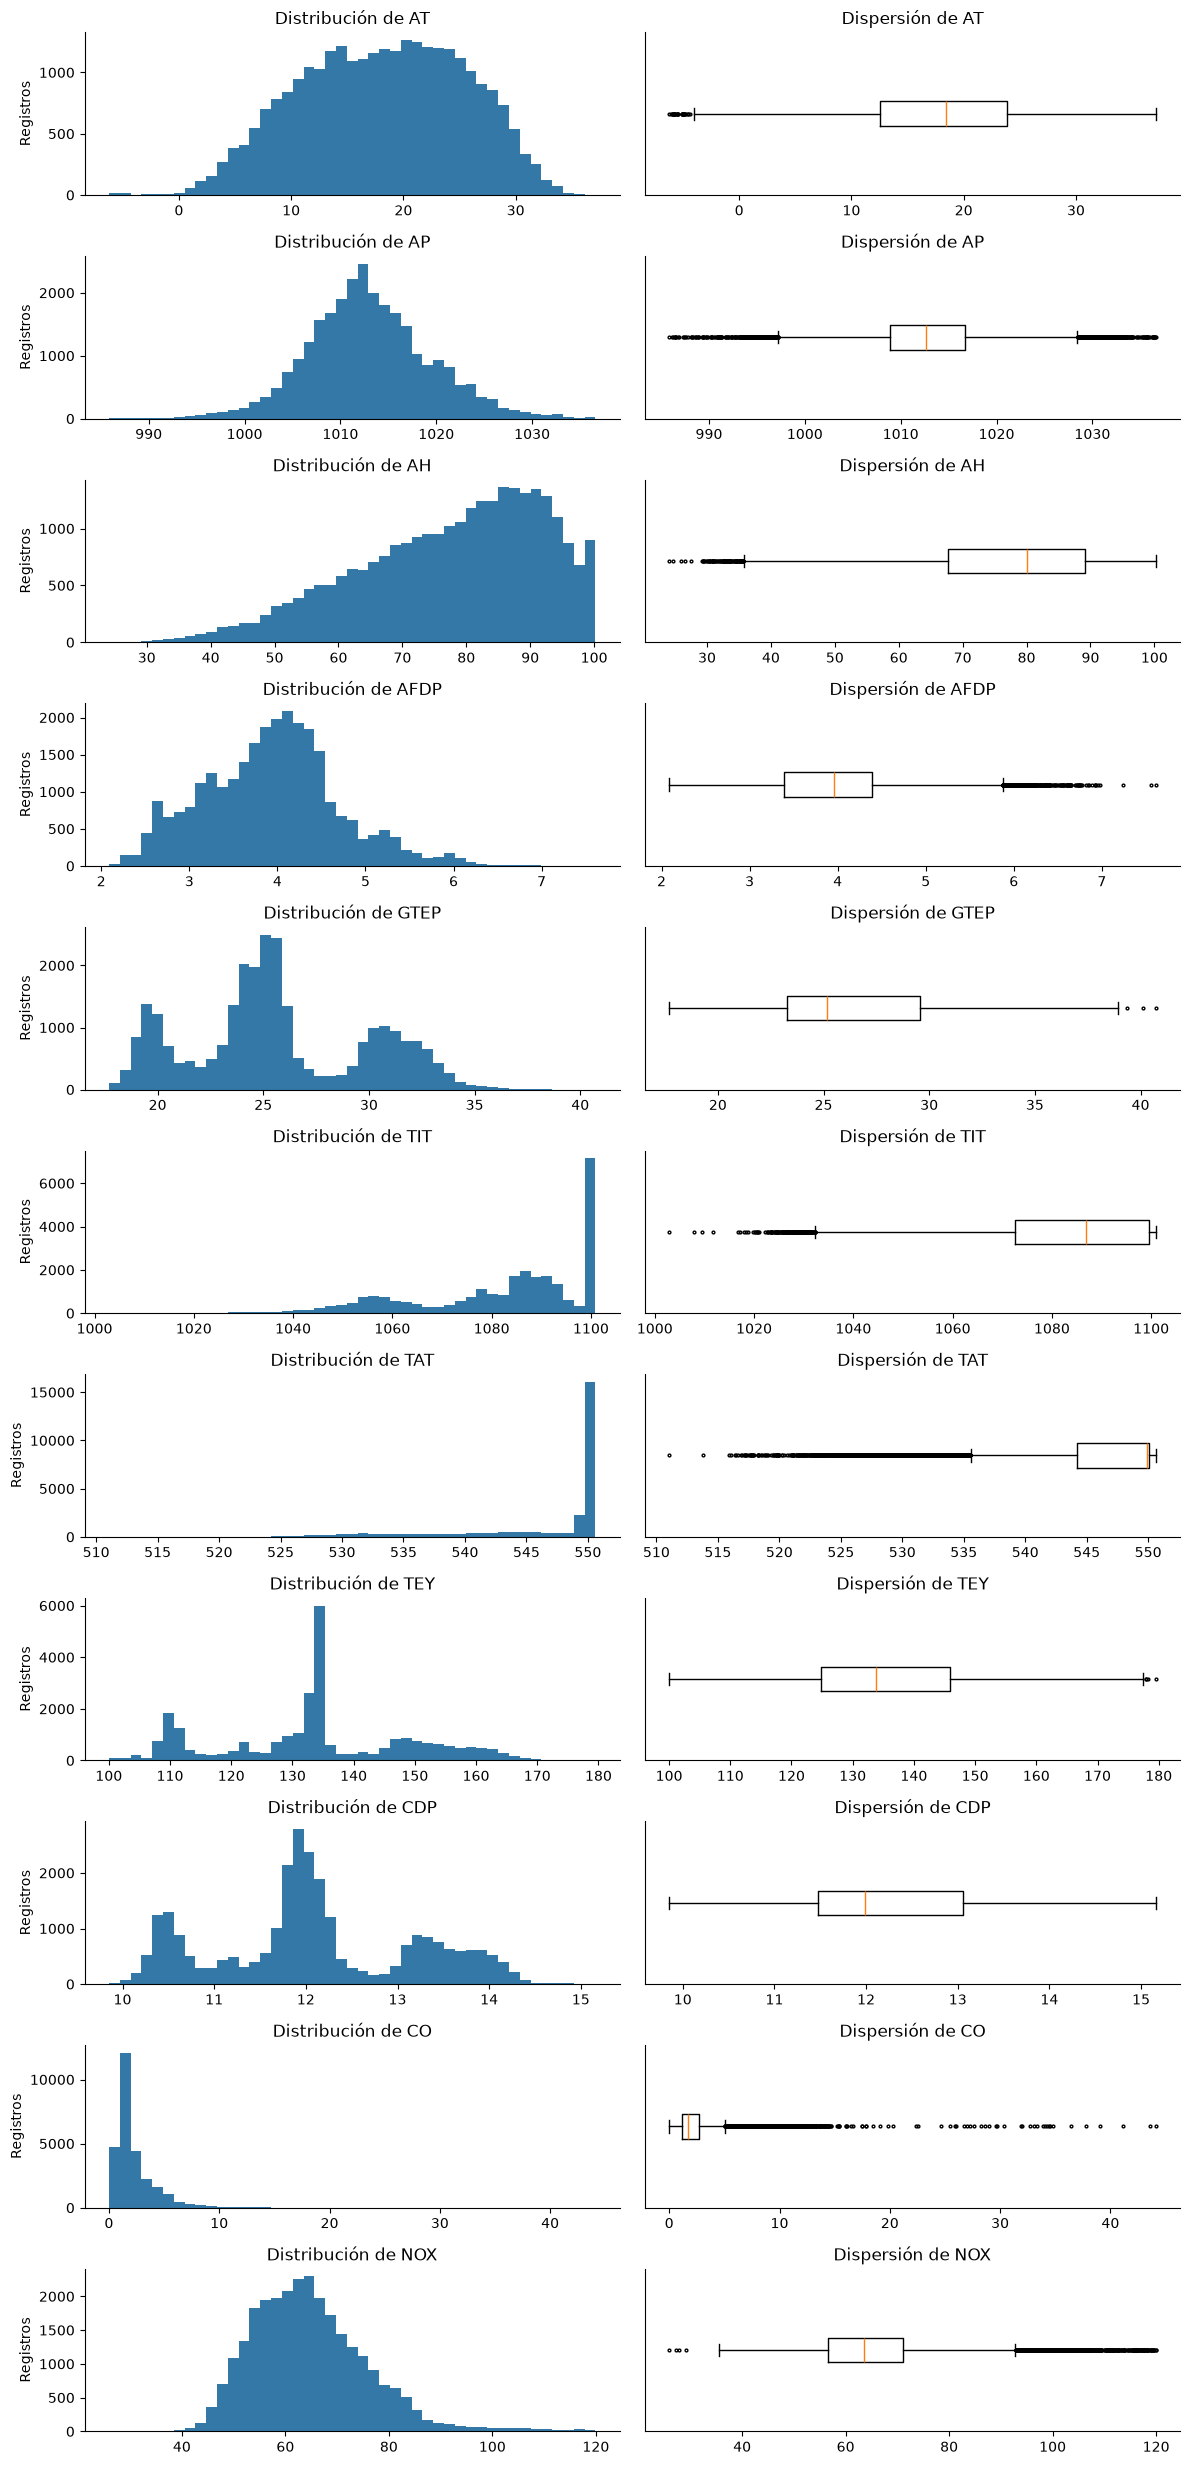

,limite_inferior,limite_superior,porcentaje_marcado
AT,-4.285,40.688,0.109
AP,997.200,1028.400,2.579
AH,35.669,121.194,0.366
AFDP,1.908,5.872,1.639
GTEP,13.800,39.007,0.011
TIT,1032.250,1139.850,0.638
TAT,535.546,558.736,12.020
TEY,93.196,177.586,0.015
CDP,9.112,15.422,0.000
CO,-1.178,5.101,7.922


,objetivo,K2,p,p_Holm
0,CO,28416.228852,0.0,0.0
1,NOX,4313.919056,0.0,0.0


**CO:** mediana 1.693, media 2.321 mg/m³, asimetría 4.933; 7.92% marcado por IQR.

**NOX:** mediana 63.517, media 64.725 mg/m³, asimetría 0.963; 2.00% marcado por IQR.

In [5]:
resumen = df[columnas].describe(percentiles=[.01,.25,.5,.75,.95,.99]).T
resumen['asimetria'] = df[columnas].skew()
resumen['curtosis_exceso'] = df[columnas].kurt()
display(resumen.round(3))
fig, axes = plt.subplots(len(columnas),2,figsize=(12,2.25*len(columnas)))
for i,v in enumerate(columnas):
    axes[i,0].hist(df[v],bins=45,color='#3478a8')
    axes[i,0].set(title=f'Distribución de {v}',ylabel='Registros')
    axes[i,1].boxplot(df[v],vert=False,showfliers=True,flierprops={'markersize':2})
    axes[i,1].set(title=f'Dispersión de {v}',yticks=[])
plt.tight_layout(); plt.show()
q1,q3 = df[columnas].quantile(.25),df[columnas].quantile(.75)
iqr = q3-q1
extremos = pd.DataFrame({'limite_inferior':q1-1.5*iqr,'limite_superior':q3+1.5*iqr,
                        'porcentaje_marcado':100*((df[columnas]<q1-1.5*iqr)|(df[columnas]>q3+1.5*iqr)).mean()})
display(extremos.round(3))
pruebas = pd.DataFrame([{'objetivo':t,'K2':stats.normaltest(df[t]).statistic,'p':stats.normaltest(df[t]).pvalue} for t in OBJETIVOS])
pruebas['p_Holm'] = multipletests(pruebas.p,method='holm')[1]
display(pruebas)
for t in OBJETIVOS:
    display(Markdown(f'**{t}:** mediana {df[t].median():.3f}, media {df[t].mean():.3f} mg/m³, '
                     f'asimetría {df[t].skew():.3f}; {extremos.loc[t,"porcentaje_marcado"]:.2f}% marcado por IQR.'))

Los histogramas muestran qué valores son frecuentes y si existe una cola de mediciones altas. Los diagramas de caja resumen la mediana y la dispersión. La regla del rango intercuartílico (IQR) señala valores alejados de la zona central, pero **un valor extremo no es necesariamente una medición incorrecta**. Se conserva porque puede representar un episodio de emisiones que el modelo debería reconocer.

La prueba de normalidad contrasta la compatibilidad de la distribución marginal con una distribución gaussiana. Su rechazo no justifica por sí solo transformar la respuesta, puesto que Ridge y SVR no requieren normalidad marginal de las emisiones. Se conserva la escala de mg/m³ para interpretar el error predictivo. RMSE penaliza especialmente los errores de mayor magnitud, mientras que MAE resume el error absoluto medio. MAPE presenta limitaciones para CO debido a la presencia de concentraciones próximas a cero, que pueden generar errores porcentuales desproporcionados.

### 3.3 Asociaciones bidimensionales y multicolinealidad

,CO,NOX
AT,-0.097,-0.563
AP,0.009,0.142
AH,0.090,0.166
AFDP,-0.518,-0.139
GTEP,-0.635,-0.151
TIT,-0.687,-0.076
TAT,0.211,-0.051
TEY,-0.665,-0.009
CDP,-0.665,-0.105


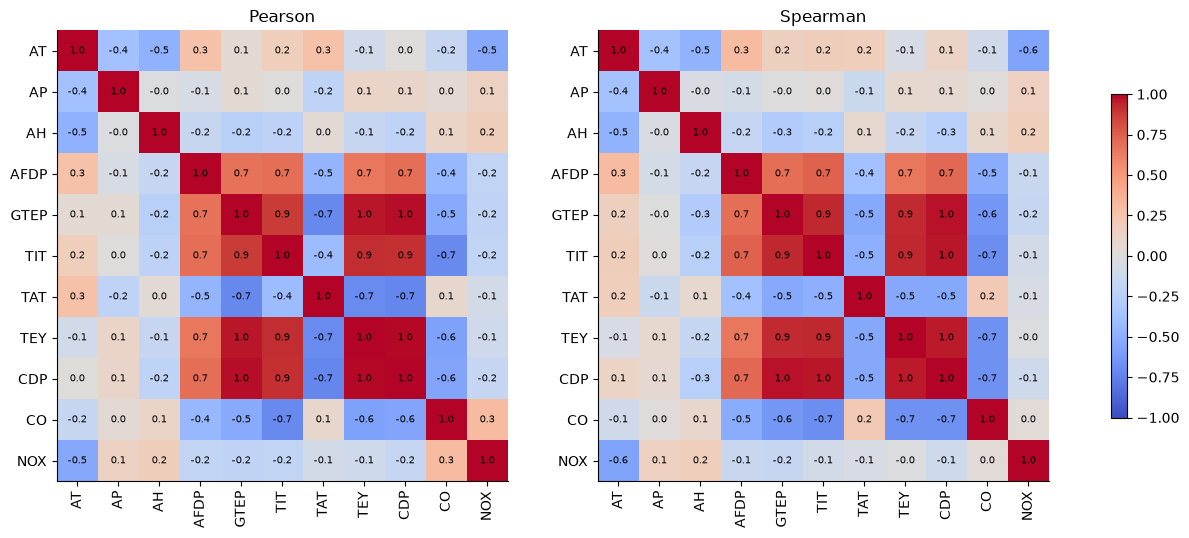

,predictor,VIF
7,TEY,259.800085
8,CDP,259.109041
5,TIT,39.168755
4,GTEP,32.472993
6,TAT,10.495597
0,AT,8.149947
3,AFDP,2.453109
2,AH,1.582718
1,AP,1.487560


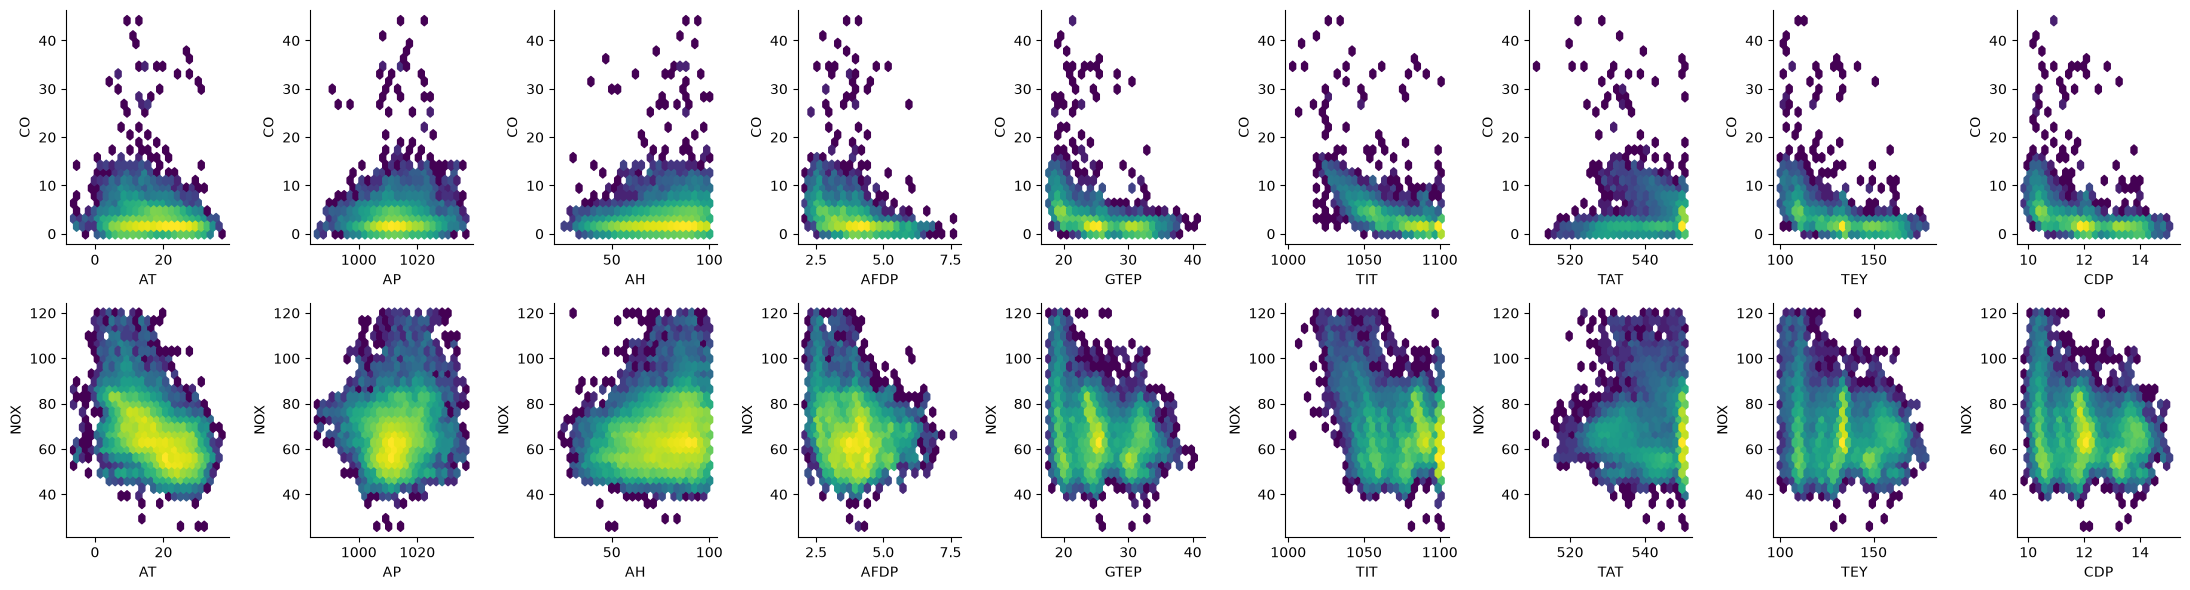

La mayor asociación monotónica de **CO** es con **TIT**, ρ = -0.687. No se interpreta como efecto causal.

La mayor asociación monotónica de **NOX** es con **AT**, ρ = -0.563. No se interpreta como efecto causal.

In [6]:
pearson = df[columnas].corr(method='pearson')
spearman = df[columnas].corr(method='spearman')
display(spearman.loc[PREDICTORES,OBJETIVOS].round(3))
fig,axes=plt.subplots(1,2,figsize=(16,6))
for ax,mat,titulo in zip(axes,[pearson,spearman],['Pearson','Spearman']):
    im=ax.imshow(mat,vmin=-1,vmax=1,cmap='coolwarm')
    ax.set(xticks=range(len(columnas)),yticks=range(len(columnas)),xticklabels=columnas,yticklabels=columnas,title=titulo)
    ax.tick_params(axis='x',rotation=90)
    for i in range(len(columnas)):
        for j in range(len(columnas)): ax.text(j,i,f'{mat.iloc[i,j]:.1f}',ha='center',va='center',fontsize=7)
fig.colorbar(im,ax=axes,shrink=.7); plt.show()
vif=[]
z=StandardScaler().fit_transform(df[PREDICTORES])
for j,v in enumerate(PREDICTORES):
    other=np.column_stack([np.ones(len(z)),np.delete(z,j,axis=1)])
    fitted=other@np.linalg.lstsq(other,z[:,j],rcond=None)[0]
    r2=r2_score(z[:,j],fitted)
    vif.append((v,1/max(1-r2,1e-12)))
display(pd.DataFrame(vif,columns=['predictor','VIF']).sort_values('VIF',ascending=False))
fig,axes=plt.subplots(2,9,figsize=(22,6))
for i,t in enumerate(OBJETIVOS):
    for j,v in enumerate(PREDICTORES):
        axes[i,j].hexbin(df[v],df[t],gridsize=25,mincnt=1,bins='log',cmap='viridis')
        axes[i,j].set(xlabel=v,ylabel=t)
plt.tight_layout(); plt.show()
for t in OBJETIVOS:
    top=spearman.loc[PREDICTORES,t].abs().idxmax()
    display(Markdown(f'La mayor asociación monotónica de **{t}** es con **{top}**, '
                     f'ρ = {spearman.loc[top,t]:.3f}. No se interpreta como efecto causal.'))

Las asociaciones entre sensores y emisiones se caracterizan mediante los coeficientes de Pearson y Spearman. Pearson cuantifica asociación lineal y Spearman asociación monotónica; ambos toman valores entre −1 y 1. Estas medidas describen dependencia estadística, pero no identifican efectos causales de las condiciones operativas sobre las emisiones.

Los gráficos de densidad hexagonal permiten identificar condiciones operativas frecuentes y posibles relaciones no lineales. El factor de inflación de varianza (VIF) cuantifica la inflación de la varianza de los coeficientes asociada a la dependencia lineal entre predictores. Un VIF elevado advierte multicolinealidad y limita la interpretación de coeficientes individuales, sin exigir automáticamente la exclusión de sensores cuando el objetivo es predictivo. La regresión Ridge incorpora regularización para reducir la inestabilidad asociada a esa dependencia.

### 3.4 Información mutua y disponibilidad de sensores

In [7]:
muestra_mi=df.sample(min(5000,len(df)),random_state=SEMILLA)
mi=pd.DataFrame({t:mutual_info_regression(muestra_mi[PREDICTORES],muestra_mi[t],random_state=SEMILLA) for t in OBJETIVOS},index=PREDICTORES)
display(mi.round(3))

,CO,NOX
AT,0.113,0.261
AP,0.033,0.099
AH,0.036,0.042
AFDP,0.258,0.143
GTEP,0.464,0.264
TIT,0.565,0.286
TAT,0.166,0.121
TEY,0.552,0.291
CDP,0.508,0.230


La información mutua complementa las correlaciones: busca dependencia entre cada sensor y cada emisión sin exigir una relación lineal. Se estima con hasta 5.000 registros del entrenamiento por costo computacional. Un valor mayor indica más dependencia estimada, pero **no es un porcentaje de varianza explicada ni una medida causal**.

Una dependencia elevada entre un sensor y una emisión no demuestra fuga de información. La auditoría requiere verificar la procedencia de cada medición, su disponibilidad temporal y su independencia respecto del analizador de gases. No se utiliza la información mutua para seleccionar o descartar sensores; se mantienen las nueve entradas en todos los pliegues de validación por bloques.

**Prevención de fuga:** CO y NOx no se usan como entradas entre sí. También se excluyen año y posición. Antes de un uso industrial debe verificarse que los nueve sensores, incluido TEY, estén disponibles al predecir y no se calculen a partir del analizador de gases. Las coincidencias con prueba se revisan después como control de calidad, sin modificar los modelos.

### 3.4.1 Desempeño de cada sensor y auditoría predictiva de fuga

Se ajusta una regresión Ridge por sensor y emisión, con **α = 1 fijo**, sin búsqueda de hiperparámetros. Se conservan los mismos cinco pliegues por bloques y los márgenes de 24 registros del protocolo principal. Sensores y respuestas se estandarizan exclusivamente dentro del entrenamiento de cada pliegue. La prueba no interviene en esta auditoría y sus resultados no modifican la lista de sensores ni el modelo final.

R² y RMSE OOF se calculan sobre las predicciones de desarrollo obtenidas fuera del ajuste; MAE y la reducción de RMSE frente a la media de entrenamiento complementan la comparación. El promedio y la desviación de R² por pliegue describen variación entre condiciones y no equivalen al R² OOF global. RMSE y MAE se expresan en mg/m³.

Un desempeño individual cercano a R² = 1 sería una señal para investigar procedencia, derivación y disponibilidad, no una prueba automática de fuga. Un valor moderado tampoco demuestra su ausencia: relaciones no lineales y combinaciones de sensores podrían ocultar dependencias. La independencia respecto del analizador y la disponibilidad real deben confirmarse operacionalmente. Esta auditoría no estima efectos causales ni constituye selección automática de variables.


,objetivo,sensor,alpha,R2_CV_promedio,R2_CV_std,R2_OOF,RMSE_OOF,MAE_OOF,RMSE_Dummy_OOF,reduccion_RMSE_vs_Dummy_pct,n_desarrollo,n_folds
0,CO,AT,1,0.0169,0.0137,0.0212,2.1438,1.3365,2.1688,1.1516,27570,5
1,CO,AP,1,-0.0064,0.0090,-0.0017,2.1688,1.3651,2.1688,0.0018,27570,5
2,CO,AH,1,0.0073,0.0056,0.0099,2.1561,1.3588,2.1688,0.5863,27570,5
3,CO,AFDP,1,0.1830,0.0354,0.1904,1.9497,1.1726,2.1688,10.1050,27570,5
4,CO,GTEP,1,0.2746,0.0266,0.2742,1.8460,1.1036,2.1688,14.8837,27570,5
5,CO,TIT,1,0.4875,0.0472,0.4928,1.5433,0.8703,2.1688,28.8428,27570,5
6,CO,TAT,1,0.0016,0.0101,0.0058,2.1606,1.3426,2.1688,0.3772,27570,5
7,CO,TEY,1,0.3220,0.0258,0.3278,1.7766,1.0530,2.1688,18.0857,27570,5
8,CO,CDP,1,0.3032,0.0200,0.3079,1.8027,1.0690,2.1688,16.8815,27570,5
9,NOX,AT,1,0.2732,0.0505,0.2896,9.5166,7.2619,11.3712,16.3097,27570,5


**CO:** TIT alcanza el mayor R² OOF individual (0.493), con RMSE 1.543 mg/m³ y reducción de RMSE 28.8% frente a Dummy. El desempeño se interpreta como asociación predictiva bajo esta representación lineal, no como certificación de ausencia de fuga.

**NOX:** AT alcanza el mayor R² OOF individual (0.290), con RMSE 9.517 mg/m³ y reducción de RMSE 16.3% frente a Dummy. El desempeño se interpreta como asociación predictiva bajo esta representación lineal, no como certificación de ausencia de fuga.

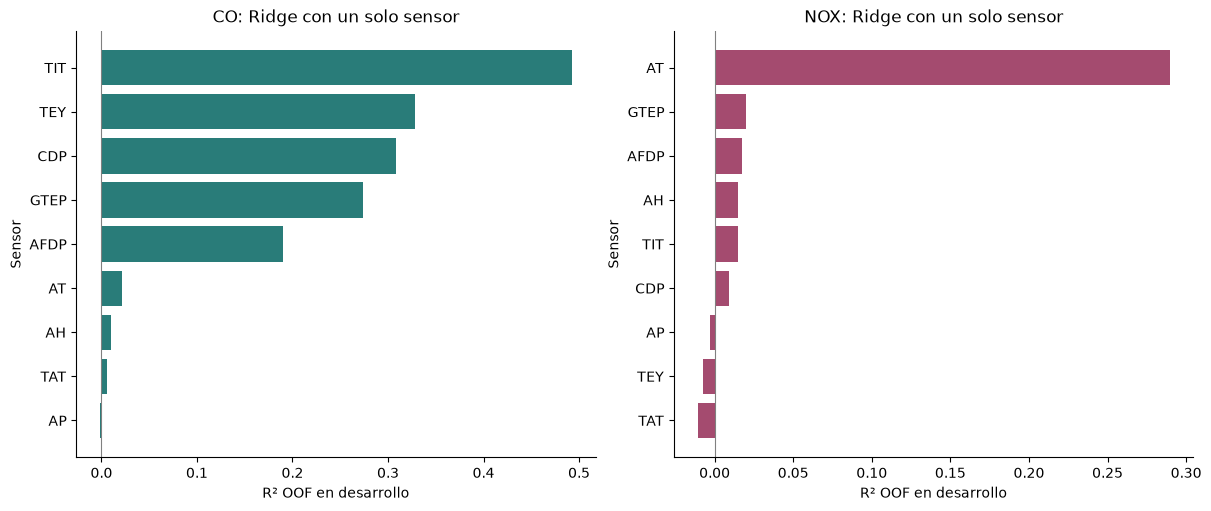

In [8]:
from auditoria_sensores import auditar_sensores
auditoria_univariada,detalle_univariado=auditar_sensores(desarrollo,splits_bloques,PREDICTORES,OBJETIVOS)
display(auditoria_univariada.round(4))
auditoria_univariada.to_csv(SALIDA/'auditoria_predictiva_univariada.csv',index=False)
detalle_univariado.to_csv(SALIDA/'auditoria_predictiva_univariada_folds.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,5),layout='constrained')
for ax,t,color in zip(axes,OBJETIVOS,['#297c79','#a44b6f']):
    tabla=auditoria_univariada[auditoria_univariada.objetivo==t].sort_values('R2_OOF')
    ax.barh(tabla.sensor,tabla.R2_OOF,color=color)
    ax.axvline(0,color='grey',lw=.8)
    ax.set(title=f'{t}: Ridge con un solo sensor',xlabel='R² OOF en desarrollo',ylabel='Sensor')
    mayor=tabla.iloc[-1]
    display(Markdown(f'**{t}:** {mayor.sensor} alcanza el mayor R² OOF individual '
        f'({mayor.R2_OOF:.3f}), con RMSE {mayor.RMSE_OOF:.3f} mg/m³ y reducción de RMSE '
        f'{mayor.reduccion_RMSE_vs_Dummy_pct:.1f}% frente a Dummy. '
        'El desempeño se interpreta como asociación predictiva bajo esta representación lineal, '
        'no como certificación de ausencia de fuga.'))
plt.show()


### 3.5 Estructura multivariada

,componente,varianza,acumulada
0,1,0.544654,0.544654
1,2,0.196619,0.741273
2,3,0.110538,0.851811
3,4,0.062724,0.914534
4,5,0.052017,0.966551
5,6,0.028028,0.994579
6,7,0.004139,0.998718
7,8,0.001046,0.999765
8,9,0.000235,1.000000


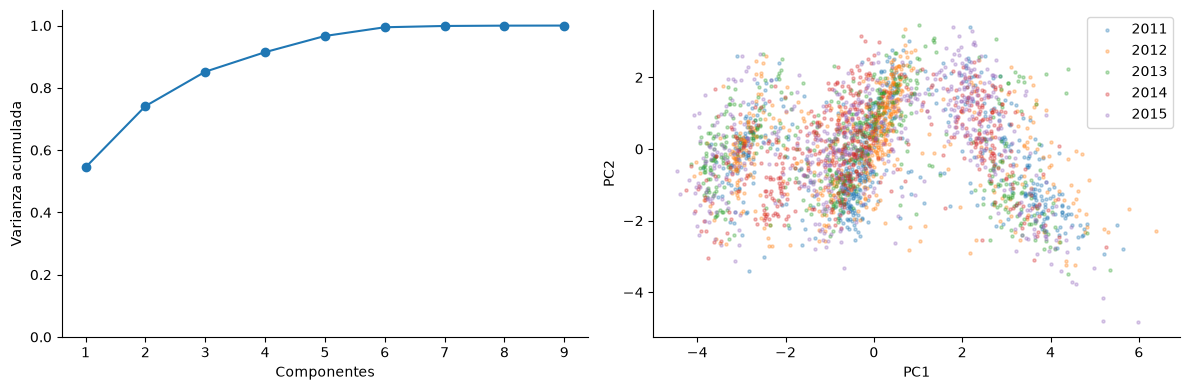

Filas señaladas por Isolation Forest: 552 (2% fijado como exploración, no tasa real de error)
Silhouette, muestra de 2.000: 0.301


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
grupo,,,,,,,,,,,
0,19.356,1012.4,80.060,3.906,25.060,1086.3,549.99,133.71,11.967,1.595,64.329
1,17.064,1012.6,84.774,3.122,19.968,1056.0,549.94,110.72,10.542,4.257,63.907
2,18.303,1013.0,74.485,4.506,31.254,1100.0,536.99,153.32,13.528,1.201,60.380


Las dos primeras componentes explican **74.1%** de la variación estandarizada. PCA, clustering e Isolation Forest son exploratorios; no modifican los predictores ni excluyen filas.

In [9]:
escala_eda=StandardScaler().fit(df[PREDICTORES])
z=escala_eda.transform(df[PREDICTORES])
pca=PCA().fit(z)
proy=pca.transform(z)
display(pd.DataFrame({'componente':np.arange(1,10),'varianza':pca.explained_variance_ratio_, 'acumulada':np.cumsum(pca.explained_variance_ratio_)}))
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(np.arange(1,10),np.cumsum(pca.explained_variance_ratio_),'o-'); axes[0].set(xlabel='Componentes',ylabel='Varianza acumulada',ylim=(0,1.05))
for a,g in df.groupby('anio'):
    idx=np.flatnonzero(df.anio.to_numpy()==a)[::10]
    axes[1].scatter(proy[idx,0],proy[idx,1],s=5,alpha=.3,label=str(a))
axes[1].set(xlabel='PC1',ylabel='PC2');axes[1].legend();plt.tight_layout();plt.show()
iso=IsolationForest(n_estimators=100,contamination=.02,random_state=SEMILLA,n_jobs=1).fit(z)
marcas=iso.predict(z)==-1
grupos=KMeans(n_clusters=3,n_init=10,random_state=SEMILLA).fit_predict(z)
print('Filas señaladas por Isolation Forest:',int(marcas.sum()), '(2% fijado como exploración, no tasa real de error)')
print('Silhouette, muestra de 2.000:',round(silhouette_score(z,grupos,sample_size=2000,random_state=SEMILLA),3))
display(df.assign(grupo=grupos).groupby('grupo')[columnas].median().round(3))
display(Markdown(f'Las dos primeras componentes explican **{100*pca.explained_variance_ratio_[:2].sum():.1f}%** de la variación estandarizada. '
                 'PCA, clustering e Isolation Forest son exploratorios; no modifican los predictores ni excluyen filas.'))

PCA resume los nueve sensores en combinaciones llamadas componentes. El gráfico de varianza indica cuántas se necesitan para conservar gran parte de la variación observada; el plano PC1-PC2 permite ver si los años ocupan regiones parecidas. Esto describe los sensores, no demuestra que las componentes con más variación sean las más útiles para predecir emisiones.

KMeans agrupa registros con configuraciones similares y el índice silhouette resume su separación: valores cercanos a 1 indican grupos bien separados, valores cercanos a 0 indican solapamiento y valores negativos sugieren asignaciones poco claras. No se identifican los grupos como cargas o regímenes físicos sin documentación operativa. Isolation Forest señala configuraciones poco habituales; el 2% marcado es un parámetro elegido para explorar, no una tasa demostrada de errores. **Estos análisis no eliminan filas ni modifican los modelos base.**

### 3.6 Dependencia temporal y heterogeneidad interanual, 2011–2015

El diagnóstico de los **36.733 registros de 2011–2015** distingue tres propiedades: variación del nivel de las emisiones, dependencia entre observaciones próximas y heterogeneidad de las distribuciones anuales. Estas propiedades no son equivalentes y su presencia no constituye evidencia de envejecimiento de la turbina. El análisis es descriptivo retrospectivo y utiliza las secuencias anuales originales, no una concatenación de bloques de desarrollo separados. La selección de hiperparámetros utiliza solo los pliegues de desarrollo.

Los archivos identifican el año y el orden cronológico de los registros, pero no incluyen fechas y horas exactas. En consecuencia, el eje temporal representa la posición de cada observación en la secuencia, y el rezago indica el número de posiciones que separan dos registros. Aunque las mediciones son agregaciones horarias, no puede verificarse la continuidad del muestreo. Esta limitación impide identificar con precisión ciclos de calendario, intervalos sin observaciones y fechas de cambio estructural.

#### 3.6.1 Evolución del nivel y la dispersión

La media y la desviación estándar de los cinco años describen el nivel y la dispersión de las emisiones. Las trayectorias se complementan con una **media móvil de 200 registros**, calculada por separado dentro de cada año para evitar combinar periodos. Las líneas verticales identifican las fronteras anuales. Los diagramas de caja permiten comparar medianas y dispersión en 2011–2015; la omisión visual de puntos extremos no implica su exclusión del análisis ni de los datos de desarrollo.

#### 3.6.2 Autocorrelación de las emisiones

La función de autocorrelación (**ACF**) cuantifica la asociación lineal entre emisiones separadas por un número determinado de registros. La función de autocorrelación parcial (**PACF**) estima esa asociación tras controlar los rezagos intermedios. Ambas se calculan **por separado para cada año y contaminante**, sin concatenar fronteras anuales. Se presentan 40 rezagos para ACF y 20 para PACF, con escalas comunes para comparar los cinco periodos. Los coeficientes toman valores entre −1 y 1; la autocorrelación en rezago cero es igual a 1 por definición.

La autocorrelación positiva en los primeros rezagos indica persistencia local de los niveles observados y reduce la información efectiva respecto de una muestra de igual tamaño formada por observaciones independientes. Este diagnóstico fundamenta las precauciones de validación y estimación de incertidumbre, sin modificar la tarea de regresión basada en sensores contemporáneos ni introducir emisiones rezagadas como predictores.

#### 3.6.3 Pruebas de estacionariedad y diferencias interanuales

Las pruebas ADF y KPSS contrastan hipótesis diferentes sobre la estacionariedad y se aplican a cada combinación de año y contaminante, con 24 rezagos y término constante. Kruskal–Wallis complementa el diagnóstico mediante la comparación de las distribuciones de **los cinco años** para cada sensor y emisión, con ajuste de Holm para las once comparaciones entre variables. Ninguna de estas pruebas establece por sí sola la estabilidad futura del desempeño predictivo.

| Indicador | Propiedad evaluada | Interpretación |
|---|---|---|
| `ADF_p` | Hipótesis nula de raíz unitaria, una forma específica de persistencia de las perturbaciones | Un valor p pequeño aporta evidencia contra esa hipótesis; no demuestra estabilidad de la media o del modelo |
| `KPSS_p` | Hipótesis nula de estacionariedad alrededor de un nivel constante | Un valor p pequeño aporta evidencia contra esa hipótesis |
| `ACF_lag1` | Asociación lineal entre registros consecutivos | Valores positivos próximos a 1 indican dependencia fuerte |
| `H`, `p` y `p_Holm` | Heterogeneidad interanual mediante Kruskal–Wallis | `H` es el estadístico; `p_Holm` ajusta los valores p por comparaciones múltiples |
| `epsilon2` | Tamaño de efecto de la heterogeneidad interanual | Valores mayores indican diferencias más marcadas; no equivale al R² predictivo |

ADF y KPSS se aplican solo como comprobaciones exploratorias: las fechas ausentes impiden verificar el espaciado regular que requiere una interpretación temporal completa. Los valores p de Kruskal–Wallis tampoco deben tomarse como evidencia definitiva porque los registros están correlacionados. Las definiciones de las dos primeras pruebas pueden consultarse en la documentación de [ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) y [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html).

AT             AP           AH         AFDP         GTEP        ...  \
       mean   std     mean   std   mean    std  mean   std   mean   std  ...   
anio                                                                     ...   
2011  17.11  7.43  1014.17  6.29  79.17  13.47  4.09  0.66  25.66  4.33  ...   
2012  18.40  7.66  1012.26  6.38  79.07  14.11  4.31  0.83  25.18  4.01  ...   
2013  17.60  6.86  1012.00  6.29  80.46  14.13  3.70  0.81  25.11  4.35  ...   
2014  18.22  6.99  1012.38  5.97  82.14  13.00  3.91  0.71  25.74  3.68  ...   
2015  17.23  8.10  1014.51  6.90  68.65  13.54  3.60  0.61  26.13  4.47  ...   

         TAT           TEY           CDP          CO          NOX         
        mean   std    mean    std   mean   std  mean   std   mean    std  
anio                                                                      
2011  544.50  8.29  135.75  16.21  12.21  1.15  1.57  1.85  67.58  10.68  
2012  546.26  7.33  132.68  15.30  12.00  1.05  2.36  2.47  68.79  10.22  
2013  545.78  7.36  132.17  16.35  11.97  1.13  2.72  2.36  70.01  12.05  
2014  547.64  4.61  132.91  13.60  12.02  0.95  2.08  2.01  60.07   9.97  
2015  546.64  5.49  133.99  16.18  12.10  1.14  3.13  2.23  59.89  11.13  

[5 rows x 22 columns]

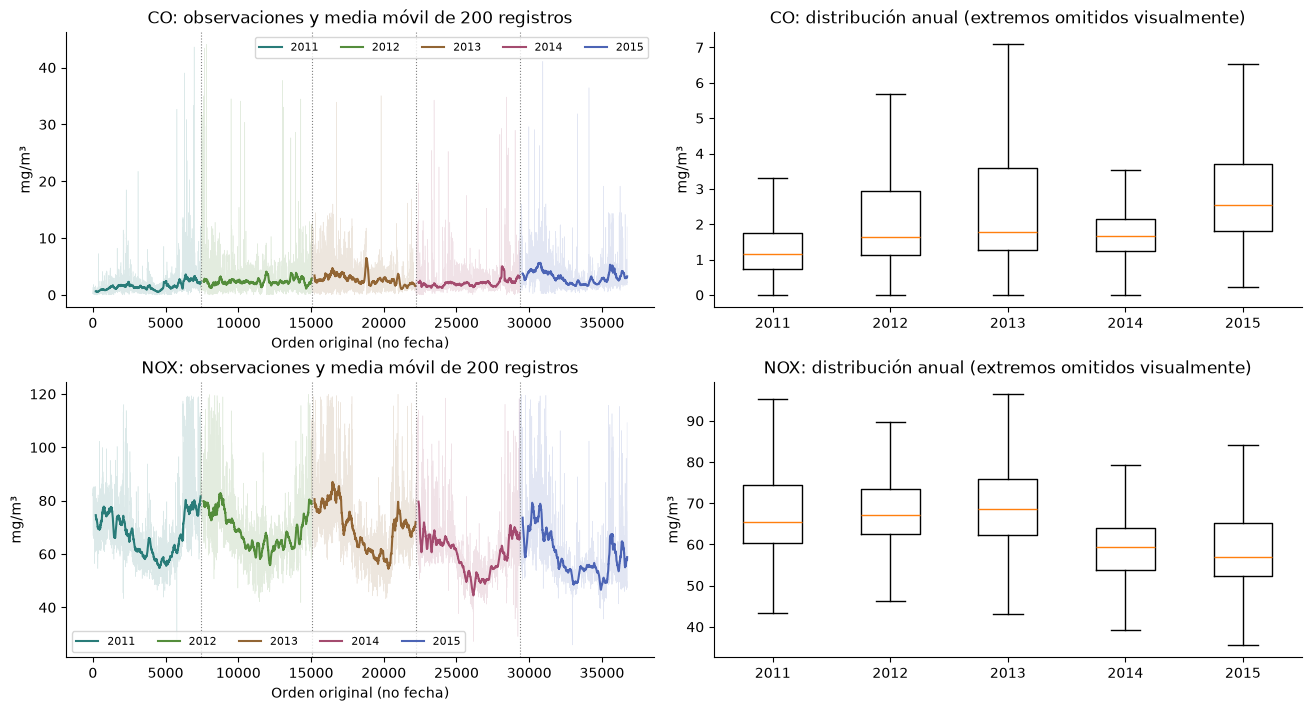

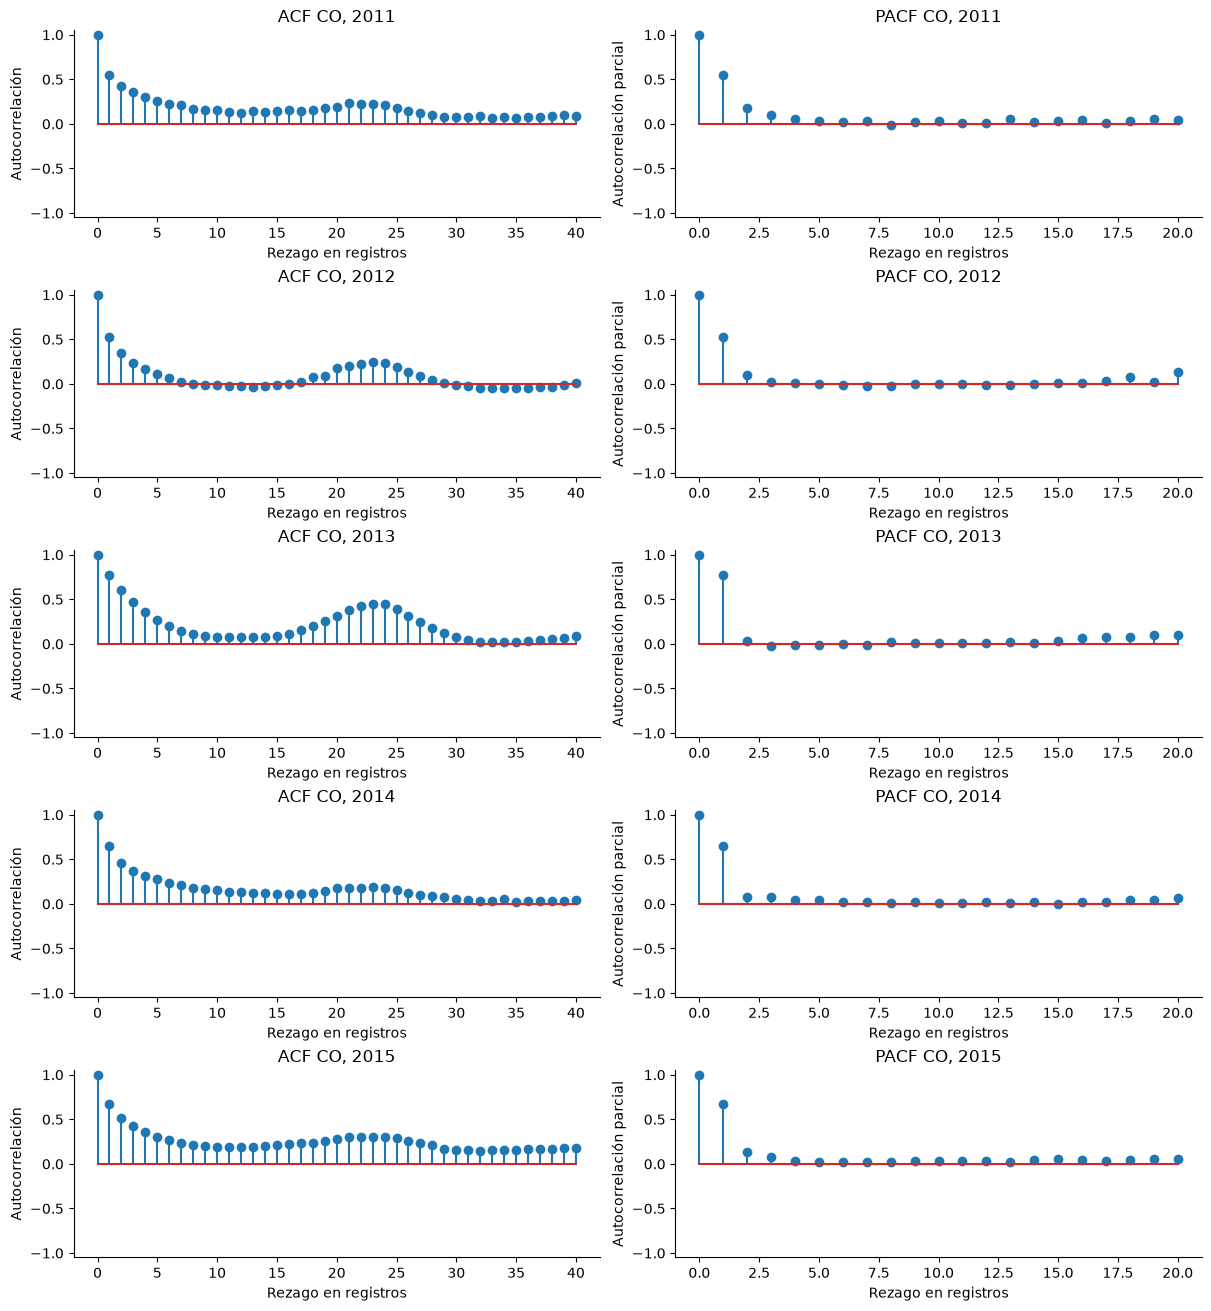

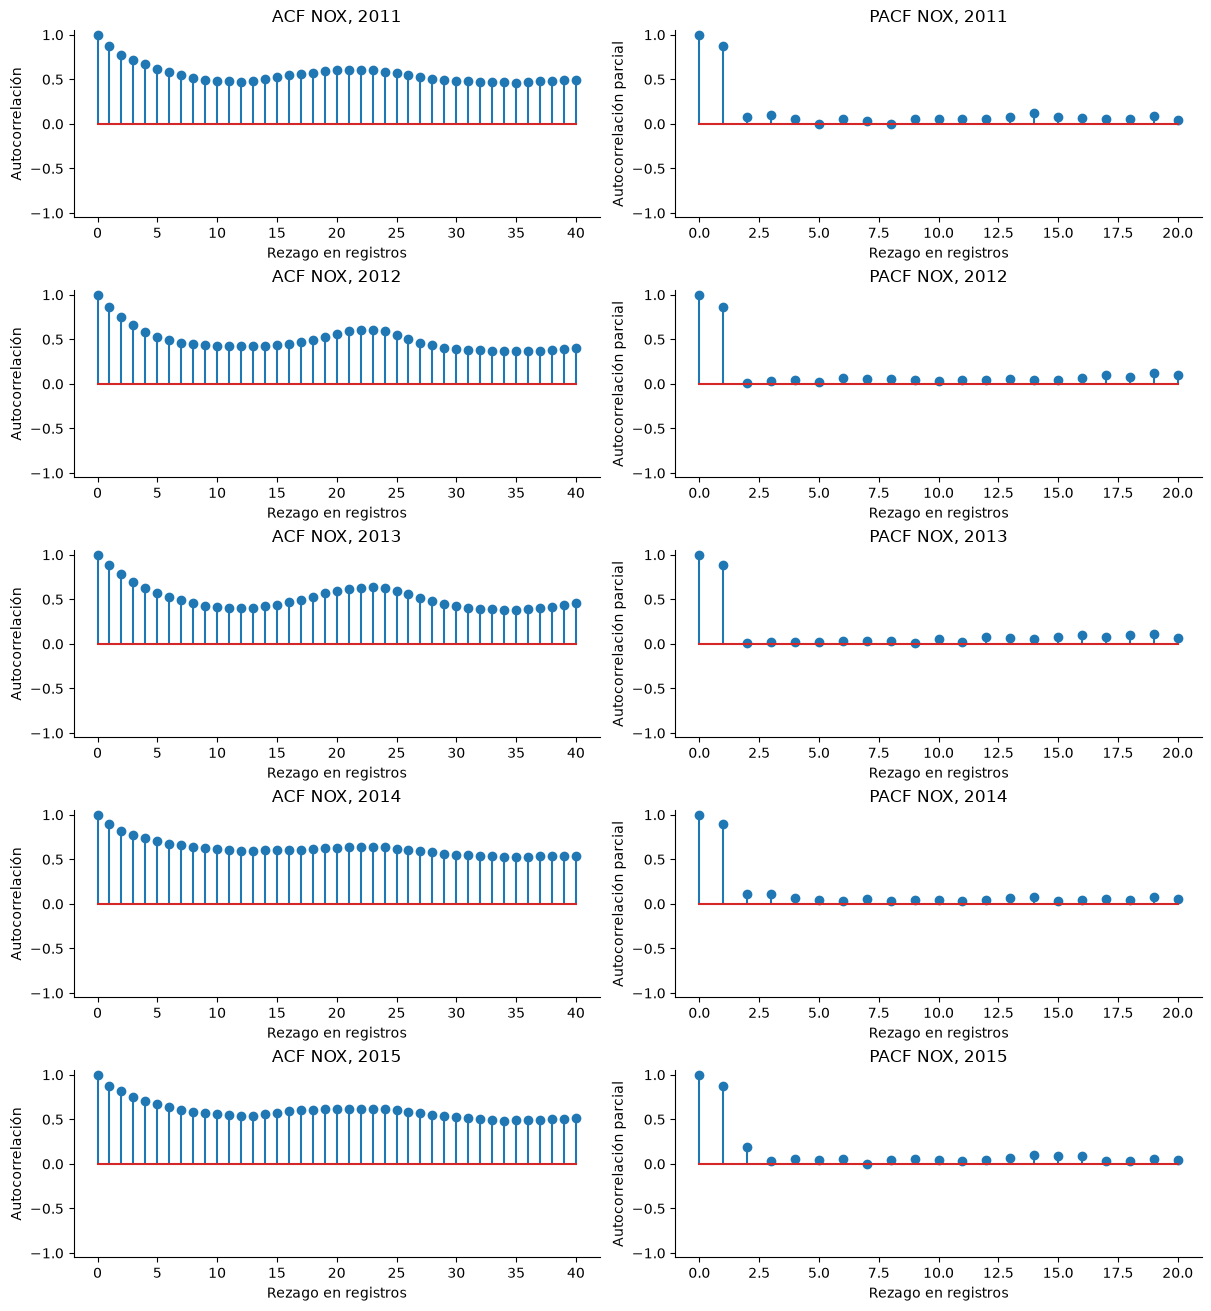

,anio,objetivo,n,ADF_p,KPSS_p,ACF_lag1
0,2011,CO,7411,3.582e-16,0.010,0.553
1,2011,NOX,7411,1.010e-05,0.010,0.871
2,2012,CO,7628,3.298e-18,0.018,0.525
3,2012,NOX,7628,1.602e-06,0.010,0.864
4,2013,CO,7152,2.951e-11,0.010,0.773
5,2013,NOX,7152,2.338e-05,0.010,0.883
6,2014,CO,7158,1.326e-18,0.010,0.646
7,2014,NOX,7158,2.512e-05,0.010,0.894
8,2015,CO,7384,2.433e-12,0.010,0.667
9,2015,NOX,7384,7.381e-06,0.010,0.878


,variable,n,anios_comparados,H,p,epsilon2,p_Holm
0,AT,36733,5,175.368,7.363e-37,0.0047,1.473e-36
1,AP,36733,5,820.810,2.386e-176,0.0222,1.432e-175
2,AH,36733,5,4097.121,0.000e+00,0.1114,0.000e+00
3,AFDP,36733,5,4186.874,0.000e+00,0.1139,0.000e+00
4,GTEP,36733,5,167.382,3.813e-35,0.0044,3.813e-35
5,TIT,36733,5,917.761,2.363e-197,0.0249,1.654e-196
6,TAT,36733,5,326.145,2.475e-69,0.0088,1.238e-68
7,TEY,36733,5,298.647,2.122e-63,0.0080,8.488e-63
8,CDP,36733,5,204.502,4.044e-43,0.0055,1.213e-42
9,CO,36733,5,5520.960,0.000e+00,0.1502,0.000e+00


In [10]:
datos_temporales = datos.sort_values('orden_registro').copy()
anios_temporales = sorted(datos_temporales.anio.unique())
assert anios_temporales == [2011,2012,2013,2014,2015]
SALIDA_TEMPORAL = RAIZ/'informe_resultados'/'analisis_temporal_2011_2015'
SALIDA_TEMPORAL.mkdir(parents=True,exist_ok=True)
display(datos_temporales.groupby('anio')[columnas].agg(['mean','std']).round(2))
colores_temporales = {2011:'#297c79',2012:'#548d3b',2013:'#926534',2014:'#a44b6f',2015:'#4c64b5'}
fig,axes=plt.subplots(2,2,figsize=(13,7),layout='constrained')
for i,t in enumerate(OBJETIVOS):
    for anio,g in datos_temporales.groupby('anio',sort=True):
        color=colores_temporales[anio]
        axes[i,0].plot(g.orden_registro,g[t],alpha=.16,lw=.4,color=color)
        axes[i,0].plot(g.orden_registro,g[t].rolling(200,min_periods=200).mean(),
                       color=color,lw=1.5,label=str(anio))
    for anio in anios_temporales[1:]:
        axes[i,0].axvline(datos_temporales.loc[datos_temporales.anio==anio,'orden_registro'].min(),
                          color='grey',ls=':',lw=.8)
    axes[i,0].set(title=f'{t}: observaciones y media móvil de 200 registros',
                   xlabel='Orden original (no fecha)',ylabel='mg/m³')
    axes[i,0].legend(ncol=5,fontsize=8)
    axes[i,1].boxplot([g[t].to_numpy() for _,g in datos_temporales.groupby('anio',sort=True)],
                      tick_labels=list(map(str,anios_temporales)),showfliers=False)
    axes[i,1].set(title=f'{t}: distribución anual (extremos omitidos visualmente)',ylabel='mg/m³')
plt.show()
dependencia=[]
for t in OBJETIVOS:
    fig,axes=plt.subplots(len(anios_temporales),2,figsize=(12,13),layout='constrained')
    for i,anio in enumerate(anios_temporales):
        serie=datos_temporales.loc[datos_temporales.anio==anio,t].to_numpy()
        a=acf(serie,nlags=40,fft=True);p=pacf(serie,nlags=20,method='ywm')
        axes[i,0].stem(np.arange(len(a)),a)
        axes[i,0].set(title=f'ACF {t}, {anio}',xlabel='Rezago en registros',
                      ylabel='Autocorrelación',ylim=(-1.05,1.05))
        axes[i,1].stem(np.arange(len(p)),p)
        axes[i,1].set(title=f'PACF {t}, {anio}',xlabel='Rezago en registros',
                      ylabel='Autocorrelación parcial',ylim=(-1.05,1.05))
        with warnings.catch_warnings(record=True) as avisos:
            warnings.simplefilter('always')
            adf=adfuller(serie,maxlag=24,autolag=None,regression='c')
            kp=kpss(serie,regression='c',nlags=24)
        dependencia.append({'anio':anio,'objetivo':t,'n':len(serie),'ADF_p':adf[1],
                            'KPSS_p':kp[1],'ACF_lag1':a[1],
                            'avisos_KPSS':'; '.join(str(w.message) for w in avisos)})
    plt.show()
dependencia=pd.DataFrame(dependencia).sort_values(['anio','objetivo']).reset_index(drop=True)
assert len(dependencia)==10 and dependencia.n.sum()==2*len(datos_temporales)
display(dependencia[['anio','objetivo','n','ADF_p','KPSS_p','ACF_lag1']].style.format(
    {'ADF_p':'{:.3e}','KPSS_p':'{:.3f}','ACF_lag1':'{:.3f}'}))
dependencia.to_csv(SALIDA_TEMPORAL/'dependencia_por_anio.csv',index=False)
deriva=[]
k=len(anios_temporales)
for v in columnas:
    h,p=stats.kruskal(*(g[v].to_numpy() for _,g in datos_temporales.groupby('anio')))
    deriva.append({'variable':v,'n':len(datos_temporales),'anios_comparados':k,
                   'H':h,'p':p,'epsilon2':max(0,(h-k+1)/(len(datos_temporales)-k))})
deriva=pd.DataFrame(deriva);deriva['p_Holm']=multipletests(deriva.p,method='holm')[1]
display(deriva.style.format({'H':'{:.3f}','p':'{:.3e}','p_Holm':'{:.3e}','epsilon2':'{:.4f}'}))
deriva.to_csv(SALIDA_TEMPORAL/'heterogeneidad_cinco_anios.csv',index=False)

#### 3.6.4 Interpretación de los resultados

La autocorrelación de primer rezago evidencia persistencia local en los cinco años:

| Año | ACF de primer rezago: CO | ACF de primer rezago: NOx |
|---|---:|---:|
| 2011 | 0,553 | 0,871 |
| 2012 | 0,525 | 0,864 |
| 2013 | 0,773 | 0,883 |
| 2014 | 0,646 | 0,894 |
| 2015 | 0,667 | 0,878 |

NOx presenta dependencia de primer rezago más intensa que CO en todos los periodos, incluidos **2014 y 2015**. El número de registros no equivale al número de observaciones independientes y la estimación de incertidumbre debe considerar su organización temporal.

La media de CO aumenta de **1,57 mg/m³ en 2011 a 2,72 en 2013**, disminuye a **2,08 en 2014** y aumenta a **3,13 en 2015**. NOx pasa de **67,58 a 70,01 mg/m³ entre 2011 y 2013**, pero desciende a **60,07 en 2014 y 59,89 en 2015**. Los diagramas de caja y las trayectorias reflejan esta heterogeneidad, cuya magnitud y forma se examinan en 3.7.

La comparación Kruskal–Wallis de los **cinco años** presenta tamaños de efecto ε² de aproximadamente **0,150 para CO y 0,185 para NOx**. Estos indicadores describen diferencias interanuales de rangos y no equivalen a capacidad predictiva ni identifican su mecanismo causal. La significación estadística no equivale a relevancia práctica; la dependencia serial limita la interpretación inferencial. Los valores p iguales a cero corresponden a límites de precisión numérica, no a certeza absoluta.

Bajo la especificación utilizada, ADF y KPSS presentan valores p inferiores a 0,05 en las **diez combinaciones de año y emisión**. Los resultados aportan evidencia exploratoria contra la raíz unitaria y contra la estacionariedad alrededor de un nivel constante, respectivamente. No son necesariamente contradictorios: la ausencia de raíz unitaria no garantiza estabilidad de la media. KPSS informa aproximadamente **0,018 para CO en 2012**; en las demás combinaciones alcanza el límite inferior de **0,01** de su tabla de referencia. Estos límites no deben interpretarse como probabilidades estimadas con precisión exacta.

En conjunto, la persistencia local justifica agrupar registros consecutivos y excluir vecinos inmediatos del ajuste. La heterogeneidad interanual exige delimitar la población de generalización: el protocolo principal representa condiciones de los cinco años, pero no evalúa transferencia a un periodo futuro. Ni los bloques ni el margen de 24 registros garantizan independencia; la sensibilidad al diseño y la incertidumbre deben acompañar las métricas. La atribución de los cambios a desgaste, mantenimiento o combustible requiere información operativa adicional.

### 3.7 Magnitud y evolución de los cambios de distribución, 2011–2015

Se analizan los **36.733 registros de 2011–2015**, incluidos los periodos de desarrollo y prueba, para caracterizar retrospectivamente la evolución de las emisiones y de las condiciones operativas. Este análisis es descriptivo y no interviene en la selección de predictores, el preprocesamiento o los hiperparámetros. Los diagnósticos no alteran las asignaciones de bloques ni incorporan registros de prueba al ajuste. Los resultados de esta sección no constituyen una validación independiente de decisiones futuras.

#### 3.7.1 Caracterización anual y local

Para cada año se estiman media, mediana, desviación estándar y percentiles 10 y 90. La evolución local se resume mediante grupos de 168 registros consecutivos, sin combinar años. Las bandas entre los percentiles 10 y 90 representan dispersión de las mediciones, **no intervalos de confianza de la media**. Las funciones de distribución acumulada describen la proporción de observaciones que no supera cada concentración. El mapa de medias anuales utiliza como referencia la media y la desviación estándar de los **27.570 registros elegibles de desarrollo, 2011–2015**, manteniendo una escala común para los cinco periodos. Esta normalización descriptiva no sustituye el escalado interno de cada entrenamiento de validación por bloques.

#### 3.7.2 Diferencias entre años consecutivos

Se comparan los pares 2011–2012, 2012–2013, 2013–2014 y 2014–2015. Las diferencias de media y mediana se definen como **año posterior menos año anterior**. Además de las unidades originales, se presenta el cambio medio dividido por la desviación estándar del desarrollo elegible de los cinco años. Esta normalización facilita la comparación de magnitudes entre sensores y emisiones sin utilizar registros de prueba para definir la escala.

| Indicador | Definición e interpretación |
|---|---|
| `delta_media` / `delta_mediana` | Diferencia de promedio o mediana en las unidades originales de cada variable |
| `delta_media_SD_train` | Diferencia de promedio dividida por la desviación estándar del entrenamiento; −0,5 equivale a una caída de media desviación estándar |
| `Wasserstein_SD_train` | Distancia entre distribuciones expresada en esa misma escala; 0 indica distribuciones coincidentes y valores mayores indican mayor separación |
| `KS_D_descriptivo` | Máxima diferencia entre las proporciones acumuladas de ambos años; toma valores entre 0 y 1 y se utiliza como medida descriptiva |
| `IC95_inf` / `IC95_sup` | Límites del intervalo bootstrap del cambio de media |
| `IC_excluye_cero` | Identifica intervalos que no contienen un cambio medio nulo, bajo los supuestos del remuestreo |

La distancia de Wasserstein resume la separación entre distribuciones en unidades de desviación estándar del entrenamiento. El estadístico de Kolmogórov–Smirnov representa la máxima diferencia entre las funciones acumuladas y se utiliza únicamente como medida descriptiva, sin valores p basados en independencia.

La incertidumbre de las diferencias de media se estima mediante **bootstrap de bloques móviles**, con 2.000 réplicas y remuestreo independiente dentro de cada año. Se emplean bloques de 168 registros y se examina la sensibilidad a longitudes de 48 y 336. Este procedimiento conserva dependencia local, aunque requiere estabilidad aproximada dentro de cada periodo. Los intervalos al 95% son marginales para cada comparación, no simultáneos para el conjunto de variables. La exclusión de cero aporta evidencia exploratoria de cambio medio bajo estos supuestos, sin identificar su causa. Dada la ausencia de fechas exactas, las longitudes de bloque no se interpretan como duraciones de calendario verificadas.

#### 3.7.3 Tendencias intraanuales y asociaciones con sensores

Las pendientes de Theil–Sen, estimadas sobre medias de bloques, resumen tendencias intraanuales resistentes a observaciones extremas. Se expresan como cambio de concentración por 1.000 posiciones en la secuencia. Kendall τ describe la dirección y consistencia de la asociación con el orden de los registros. Se excluyen de esta estimación los bloques finales con menos de 84 observaciones y no se calculan valores p que supongan independencia. Las correlaciones de Spearman entre sensores y emisiones se estiman por separado para cada año; sus variaciones describen asociaciones marginales y no demuestran cambios causales en la respuesta de la turbina.

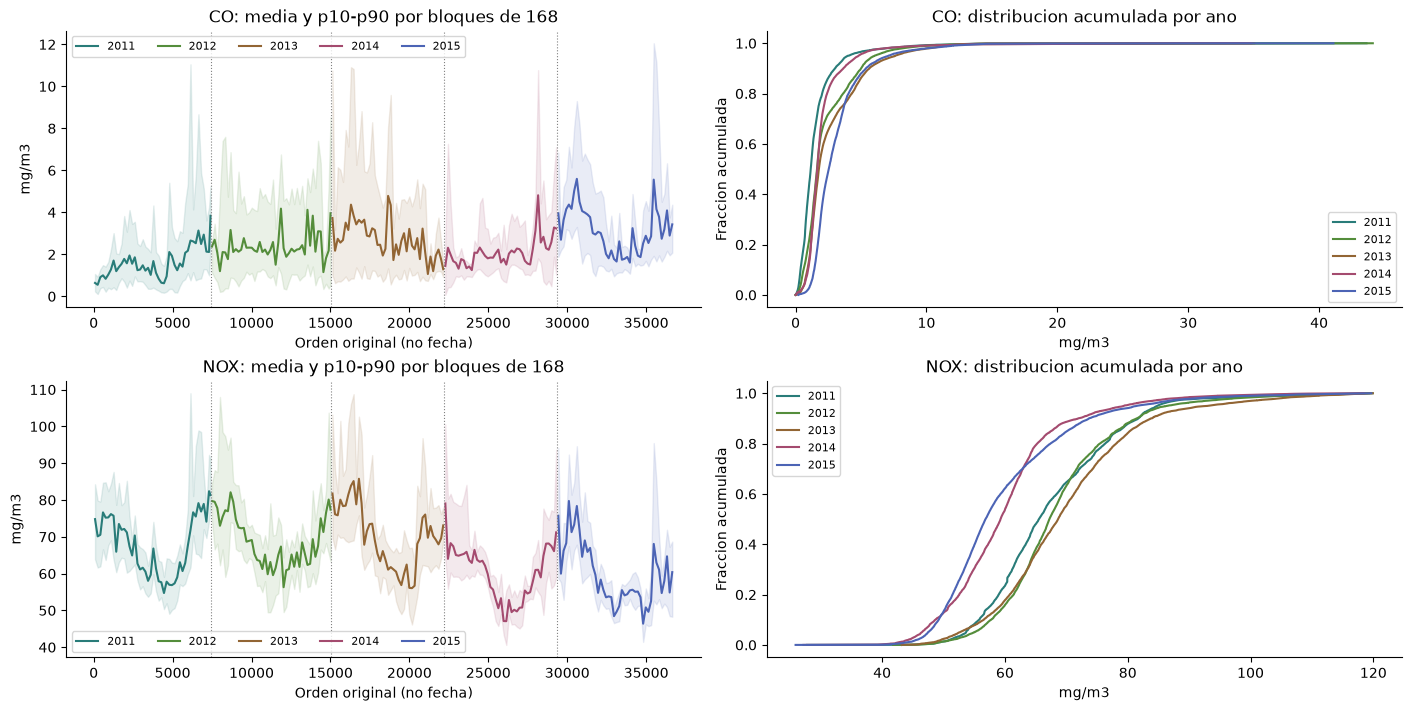

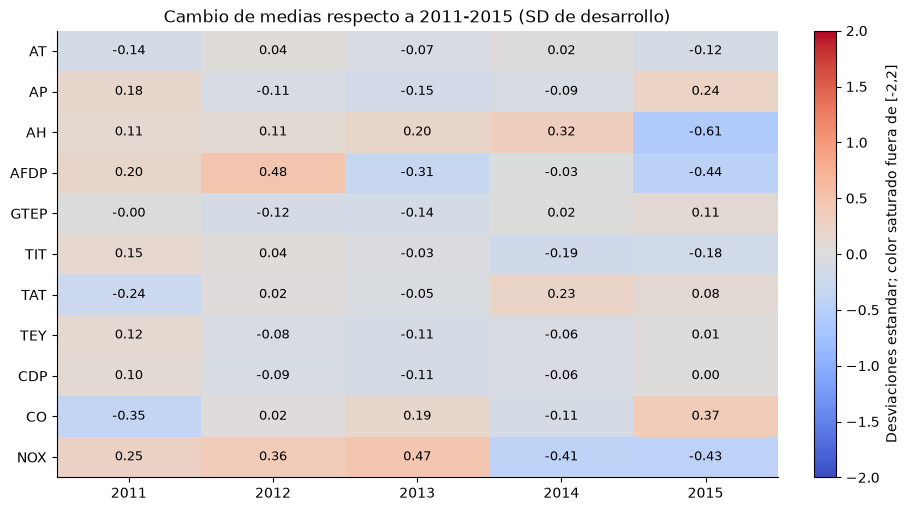

,anio,variable,n,media,mediana,std,p10,p90,desplazamiento_media_SD_train
0,2011,AT,7411,17.1123,16.3660,7.4283,7.3118,27.4210,-0.1368
1,2011,AP,7411,1014.1679,1013.6000,6.2930,1006.4000,1022.8000,0.1846
2,2011,AH,7411,79.1750,82.1290,13.4659,58.8130,94.1780,0.1147
3,2011,AFDP,7411,4.0908,4.0263,0.6619,3.1804,5.0553,0.1985
4,2011,GTEP,7411,25.6637,24.7700,4.3258,19.8770,32.1660,-0.0036
5,2011,TIT,7411,1084.7339,1088.0000,16.1350,1058.6000,1100.1000,0.1492
6,2011,TAT,7411,544.5032,549.8600,8.2885,530.2800,550.1700,-0.2364
7,2011,TEY,7411,135.7457,133.8100,16.2092,111.7500,159.5100,0.1187
8,2011,CDP,7411,12.2076,12.0080,1.1466,10.5870,13.9130,0.1032
9,2011,CO,7411,1.5725,1.1557,1.8454,0.3761,3.0058,-0.3456


,variable,desde,hasta,delta_media,delta_mediana,delta_media_SD_train,Wasserstein_SD_train,KS_D_descriptivo,IC95_inf,IC95_sup
0,AT,2011,2012,1.2857,2.7545,0.1769,0.1877,0.1254,-1.4902,4.0890
1,AP,2011,2012,-1.9097,-1.6000,-0.2937,0.2937,0.1244,-3.8366,-0.0191
2,AH,2011,2012,-0.1002,0.2825,-0.0069,0.0461,0.0278,-2.9130,2.4277
3,AFDP,2011,2012,0.2160,0.2717,0.2802,0.3535,0.2178,0.0141,0.4382
4,GTEP,2011,2012,-0.4824,0.4510,-0.1145,0.1814,0.1190,-1.2831,0.3055
5,TIT,2011,2012,-1.8437,1.1000,-0.1059,0.1265,0.1089,-4.2368,0.8654
6,TAT,2011,2012,1.7606,0.0600,0.2605,0.2622,0.1093,-0.1368,3.5734
7,TEY,2011,2012,-3.0701,-0.0500,-0.1962,0.2037,0.1188,-6.4881,0.1552
8,CDP,2011,2012,-0.2075,0.0330,-0.1896,0.2021,0.1221,-0.4160,0.0016
9,CO,2011,2012,0.7886,0.4806,0.3639,0.3640,0.2643,0.5237,1.0426


,variable,desde,hasta,bloque_registros,delta_media,IC95_inf,IC95_sup,IC_excluye_cero
27,CO,2011,2012,48,0.7886,0.5918,0.9742,True
28,CO,2011,2012,168,0.7886,0.5237,1.0426,True
29,CO,2011,2012,336,0.7886,0.4394,1.0674,True
30,NOX,2011,2012,48,1.2136,-0.5769,2.9397,False
31,NOX,2011,2012,168,1.2136,-1.6348,4.1583,False
32,NOX,2011,2012,336,1.2136,-2.6598,5.2618,False
60,CO,2012,2013,48,0.3619,0.1343,0.5778,True
61,CO,2012,2013,168,0.3619,0.0628,0.6808,True
62,CO,2012,2013,336,0.3619,0.0286,0.7427,True
63,NOX,2012,2013,48,1.2189,-0.6537,3.0408,False


,anio,objetivo,bloques_utilizados,pendiente_media_por_1000_registros,Kendall_tau_descriptivo
0,2011,CO,44,0.2045,0.4545
1,2011,NOX,44,-0.9337,-0.1078
2,2012,CO,45,0.0132,0.0747
3,2012,NOX,45,-1.6672,-0.2929
4,2013,CO,43,-0.2478,-0.4441
5,2013,NOX,43,-2.3724,-0.3599
6,2014,CO,43,0.1447,0.4308
7,2014,NOX,43,-1.2207,-0.1783
8,2015,CO,44,-0.1688,-0.2093
9,2015,NOX,44,-2.3753,-0.3721


anio              2011   2012   2013   2014   2015
objetivo sensor                                   
CO       AFDP   -0.484 -0.531 -0.546 -0.325 -0.792
         AH      0.210  0.221  0.232  0.073  0.223
         AP      0.121  0.002 -0.166  0.073  0.247
         AT     -0.172  0.025 -0.079  0.031 -0.562
         CDP    -0.648 -0.764 -0.769 -0.635 -0.737
         GTEP   -0.665 -0.765 -0.774 -0.629 -0.662
         TAT     0.196  0.213  0.203  0.204  0.235
         TEY    -0.594 -0.761 -0.742 -0.685 -0.692
         TIT    -0.667 -0.770 -0.776 -0.629 -0.771
NOX      AFDP    0.050  0.052 -0.374 -0.451 -0.562
         AH      0.197  0.031  0.153  0.049  0.019
         AP      0.389  0.086  0.108  0.378  0.177
         AT     -0.698 -0.554 -0.614 -0.741 -0.608
         CDP    -0.166 -0.112  0.031 -0.062 -0.410
         GTEP   -0.207 -0.143  0.007 -0.108 -0.307
         TAT     0.065 -0.163 -0.289 -0.113  0.109
         TEY    -0.049  0.060  0.171  0.057 -0.327
         TIT    -0.212 -0.155 -0.003 -0.113 -0.430

In [11]:
from temporal_eda import diagnostico_distribuciones
anual_total,cambios_total,ic_total,tendencias_total,corr_total = diagnostico_distribuciones(
    datos,df,columnas,OBJETIVOS,SALIDA,'cinco_anios_posthoc')
display(anual_total.round(4))
display(cambios_total.round(4))
display(ic_total[ic_total.variable.isin(OBJETIVOS)].round(4))
display(tendencias_total.round(4))
display(corr_total.pivot(index=['objetivo','sensor'],columns='anio',values='Spearman').round(3))

#### 3.7.4 Resultados e interpretación

| Año | Registros | CO: media (mg/m³) | NOx: media (mg/m³) |
|---|---:|---:|---:|
| 2011 | 7.411 | 1,57 | 67,58 |
| 2012 | 7.628 | 2,36 | 68,79 |
| 2013 | 7.152 | 2,72 | 70,01 |
| 2014 | 7.158 | 2,08 | 60,07 |
| 2015 | 7.384 | 3,13 | 59,89 |

La evolución interanual difiere entre contaminantes. **CO aumenta entre 2011 y 2013, disminuye en 2014 y alcanza su mayor media anual en 2015.** Entre 2013 y 2014, el cambio es de **−0,64 mg/m³** con un intervalo al 95% de **[−1,00; −0,32] mg/m³** para bloques de 168 registros. Entre 2014 y 2015, el aumento es de **1,05 mg/m³**, con un intervalo de **[0,68; 1,41] mg/m³**. Este patrón no es compatible con un incremento uniforme de CO a lo largo de los cinco años.

En **NOx**, el cambio más marcado ocurre entre 2013 y 2014: la media disminuye **9,94 mg/m³**; su magnitud normalizada por la dispersión del desarrollo se presenta en la tabla de cambios. El intervalo al 95% es **[−13,51; −6,77] mg/m³** y excluye cero con las tres longitudes de bloque evaluadas. Por el contrario, entre 2014 y 2015 el cambio medio es de **−0,18 mg/m³**, con un intervalo de **[−3,18; 3,21] mg/m³**. Este último resultado no aporta evidencia suficiente de una diferencia de medias bajo el procedimiento utilizado; tampoco demuestra equivalencia entre las distribuciones de ambos años.

Las funciones de distribución acumulada muestran que **NOx en 2014 y 2015 se concentra en niveles inferiores a los observados en 2011–2013**. El cambio no se limita a la media: entre 2013 y 2014, la mediana disminuye de **68,65 a 59,28 mg/m³** y el percentil 90 de **83,85 a 71,93 mg/m³**. La máxima separación entre las distribuciones acumuladas de esos dos años es **0,436**, equivalente a 43,6 puntos porcentuales en la proporción acumulada para el umbral de mayor separación.

**2014 y 2015 tampoco presentan distribuciones empíricas equivalentes, pese a sus medias similares.** La mediana de NOx disminuye de **59,28 a 56,84 mg/m³**, mientras que la desviación estándar aumenta de **9,97 a 11,13 mg/m³** y el percentil 90 pasa de **71,93 a 73,69 mg/m³**. La separación máxima entre sus distribuciones acumuladas es **0,122**. La distancia de Wasserstein, normalizada con el desarrollo elegible, se presenta en la tabla de cambios. Estos indicadores describen diferencias de localización y dispersión que la diferencia de medias no resume. No constituyen por sí solos una prueba inferencial de igualdad de distribuciones, dado el carácter dependiente de las observaciones.

Las tendencias intraanuales complementan, pero no sustituyen, las diferencias entre medias anuales. Para CO, las pendientes son **+0,14 mg/m³ por 1.000 registros en 2014** y **−0,17 en 2015**. Para NOx, son **−1,22 y −2,38**, respectivamente. Por tanto, una media anual mayor no implica necesariamente una trayectoria ascendente dentro de ese año. Estas pendientes se refieren al orden de observación, no a tasas de cambio por día o por hora.

La evidencia identifica **heterogeneidad temporal de los niveles y distribuciones**, especialmente en NOx al pasar de 2013 a 2014. Sin embargo, no permite atribuirla al paso del tiempo, al desgaste o a una intervención específica. Los cambios de condiciones operativas, combustible o calibración constituyen explicaciones alternativas no identificables con las variables disponibles. Su relación con el error predictivo se examina en la sección 4.6 mediante modelos cuya configuración permanece fija.

## 4. Modelos base y modelo final

Se conservan los nueve sensores y todas las observaciones elegibles de desarrollo. Se comparan la media de entrenamiento, Ridge y SVR lineal mediante **cinco pliegues de bloques de 168 registros**, con un margen de exclusión de 24 registros. Los sensores y cada respuesta se estandarizan exclusivamente dentro del entrenamiento de cada pliegue. Año, posición, bloque y emisiones rezagadas no se utilizan como predictores.

La referencia trivial predice la media del entrenamiento correspondiente. Ridge incorpora penalización L2; SVR lineal utiliza pérdida ε-insensible cuadrática y penalización L2. No se transforman logarítmicamente las respuestas ni se recortan predicciones negativas. Las predicciones se expresan en mg/m³.

### 4.1 Selección mediante validación por bloques

Los bloques de desarrollo se distribuyen en cinco pliegues, barajándolos dentro de cada año. Un bloque nunca aporta simultáneamente observaciones al entrenamiento y a la validación del mismo pliegue. Además, se excluyen del entrenamiento los registros a una distancia de hasta 24 posiciones de cualquier observación validada, dentro del mismo archivo anual. El margen frente a la prueba se aplica antes de construir los pliegues.

Se seleccionan los hiperparámetros por el menor **MSE medio de los cinco pliegues**, con igual peso por pliegue: α = 1, 100 y 1.000 para Ridge; C = 0,01, 0,1 y 1 y ε = 0,05 y 0,1 para SVR. La familia final de cada emisión se elige con el mismo criterio, sin usar las métricas de prueba.

Las predicciones fuera de partición (**OOF**) evalúan cada registro de desarrollo una sola vez, con un estimador que no lo utilizó en su ajuste. El promedio de R² por pliegue y el R² OOF conjunto tienen denominadores diferentes. Las métricas OOF están condicionadas a la selección de hiperparámetros con esos mismos pliegues; no equivalen a una validación anidada independiente. El conjunto de prueba permanece separado del ajuste y de la búsqueda, aunque su evaluación histórica previa limita su independencia como evidencia confirmatoria.

In [12]:
from block_model import ejecutar_experimento, metricas, predecir_final
from sklearn.base import clone
experimento = ejecutar_experimento(datos, SALIDA)
modelos = experimento['modelos']
parametros = experimento['parametros']
seleccion_final = experimento['seleccion']
resumen_cv = experimento['resumen']
np.testing.assert_array_equal(train_idx, experimento['train_idx'])
np.testing.assert_array_equal(test_idx, experimento['test_idx'])
display(experimento['conteos_folds'])
display(resumen_cv[['objetivo','modelo','parametros','seleccionado_por_CV']])
display(experimento['validacion_por_fold'][['objetivo','modelo','fold','n_train','n_val','R2','RMSE','sesgo']].round(4))
display(resumen_cv[['objetivo','modelo','R2_CV_promedio','R2_CV_std','R2_OOF','RMSE_OOF','MAE_OOF']].round(4))

,fold,n_train,n_val,n_purgados_CV
0,1,20394,5880,1296
1,2,21088,5522,960
2,3,21210,5376,984
3,4,20970,5544,1056
4,5,21146,5248,1176


,objetivo,modelo,parametros,seleccionado_por_CV
0,CO,Media,{},False
1,CO,Ridge,"{""regressor__ridge__alpha"": 1}",True
2,CO,SVR lineal,"{""regressor__linearsvr__C"": 1, ""regressor__lin...",False
3,NOX,Media,{},False
4,NOX,Ridge,"{""regressor__ridge__alpha"": 1}",True
5,NOX,SVR lineal,"{""regressor__linearsvr__C"": 1, ""regressor__lin...",False


,objetivo,modelo,fold,n_train,n_val,R2,RMSE,sesgo
0,CO,Media,1,20394,5880,-0.0020,1.9988,0.0895
1,CO,Media,2,21088,5522,-0.0041,2.1715,-0.1383
2,CO,Media,3,21210,5376,-0.0007,2.3327,-0.0634
3,CO,Media,4,20970,5544,-0.0023,2.5254,-0.1204
4,CO,Media,5,21146,5248,-0.0260,1.7209,0.2741
5,CO,Ridge,1,20394,5880,0.4572,1.4711,0.1092
6,CO,Ridge,2,21088,5522,0.5821,1.4010,-0.0241
7,CO,Ridge,3,21210,5376,0.5681,1.5324,-0.0213
8,CO,Ridge,4,20970,5544,0.5465,1.6988,-0.1250
9,CO,Ridge,5,21146,5248,0.5411,1.1509,0.0613


,objetivo,modelo,R2_CV_promedio,R2_CV_std,R2_OOF,RMSE_OOF,MAE_OOF
0,CO,Media,-0.0070,0.0107,-0.0018,2.1688,1.3680
1,CO,Ridge,0.5390,0.0486,0.5432,1.4646,0.8420
2,CO,SVR lineal,0.5382,0.0495,0.5428,1.4651,0.8471
3,NOX,Media,-0.0377,0.0325,-0.0142,11.3712,8.7524
4,NOX,Ridge,0.4933,0.0539,0.5035,7.9560,5.6603
5,NOX,SVR lineal,0.4929,0.0536,0.5032,7.9588,5.6872


### 4.2 Ajuste final y evaluación en bloques reservados

La configuración de cada familia se ajusta con los **27.570 registros de desarrollo**, procedentes de 2011–2015. Se evalúan **7.411 registros de prueba**, equivalentes al 20,18% del total, en bloques completos reservados. Los **1.752 registros del margen frente a la prueba** no se incorporan al ajuste final. La presencia de los cinco años en ambos conjuntos no implica compartir observaciones o bloques entre ellos.

Se distingue el ajuste aparente sobre desarrollo, la validación OOF y la prueba. Un R² negativo indica mayor MSE que el obtenido al predecir la media del propio conjunto evaluado; esta media no equivale necesariamente a la referencia trivial entrenada. La comparación entre entrenamiento y evaluación permite examinar sobreajuste aparente, pero no demuestra ausencia de errores por condiciones no representadas.

,objetivo,modelo,R2_train,R2_CV_promedio,R2_OOF,R2_test,RMSE_test,MAE_test,MAPE_pct_test,sesgo_test,negativos_test
0,CO,Media,0.0000,-0.0070,-0.0018,-0.0079,2.5731,1.5099,161.7321,-0.2283,0
1,CO,Ridge,0.5544,0.5390,0.5432,0.5638,1.6927,0.9394,143.9737,0.0256,3
2,CO,SVR lineal,0.5543,0.5382,0.5428,0.5650,1.6903,0.9435,144.7026,0.0350,4
3,NOX,Media,0.0000,-0.0377,-0.0142,-0.0353,12.9634,9.2763,13.3948,-2.3921,0
4,NOX,Ridge,0.5252,0.4933,0.5035,0.4741,9.2392,6.2379,9.0200,-1.3651,0
5,NOX,SVR lineal,0.5251,0.4929,0.5032,0.4766,9.2179,6.2584,9.0629,-1.3587,0


,objetivo,modelo,R2_test,RMSE_test,MAE_test,sesgo_test
1,CO,Ridge,0.5638,1.6927,0.9394,0.0256
4,NOX,Ridge,0.4741,9.2392,6.2379,-1.3651


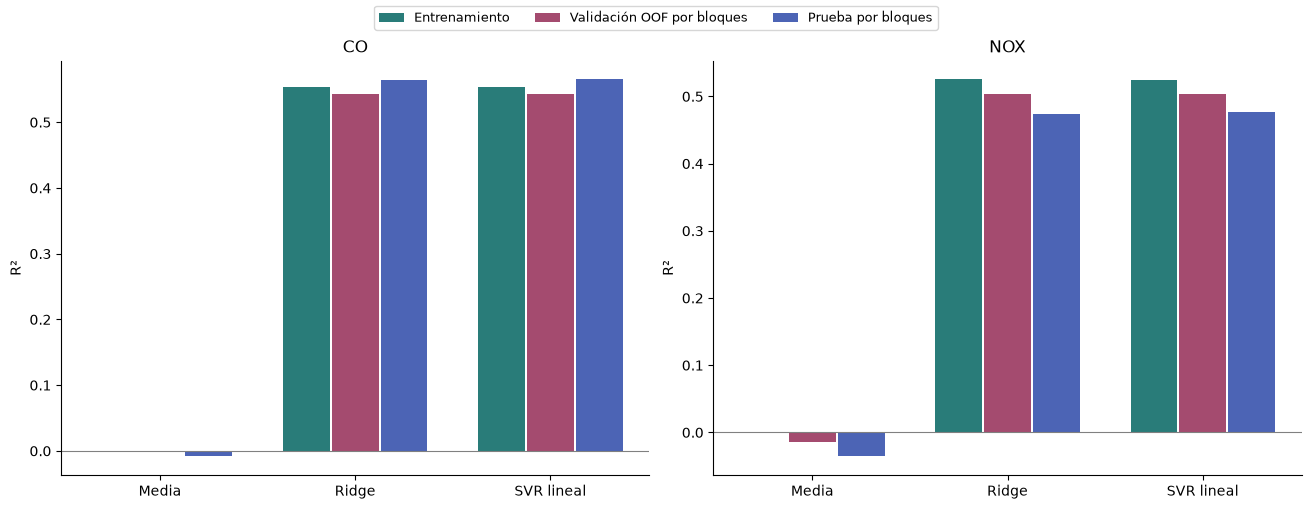

**Control de calidad:** 0 registros de prueba coinciden exactamente con registros de desarrollo. Esta auditoría no modifica la partición ni el ajuste.

In [13]:
resultados = resumen_cv.copy()
finales = resultados[resultados.seleccionado_por_CV].copy()
predicciones = {(t,nombre): modelos[t,nombre].predict(evaluacion[PREDICTORES])
               for t in OBJETIVOS for nombre in ['Media','Ridge','SVR lineal']}
display(resultados[['objetivo','modelo','R2_train','R2_CV_promedio','R2_OOF','R2_test',
                    'RMSE_test','MAE_test','MAPE_pct_test','sesgo_test','negativos_test']].round(4))
display(finales[['objetivo','modelo','R2_test','RMSE_test','MAE_test','sesgo_test']].round(4))
fig,axes=plt.subplots(1,2,figsize=(13,5),layout='constrained')
for ax,t in zip(axes,OBJETIVOS):
    r=resultados[resultados.objetivo==t].set_index('modelo').reindex(['Media','Ridge','SVR lineal'])
    posiciones=np.arange(3)
    for offset,valores,label,color in [(-.25,r.R2_train,'Entrenamiento','#297c79'),
                                      (0,r.R2_OOF,'Validación OOF por bloques','#a44b6f'),
                                      (.25,r.R2_test,'Prueba por bloques','#4c64b5')]:
        ax.bar(posiciones+offset,valores,width=.24,label=label,color=color)
    ax.axhline(0,color='grey',lw=.8)
    ax.set(xticks=posiciones,xticklabels=['Media','Ridge','SVR lineal'],ylabel='R²',title=t)
fig.legend(*axes[0].get_legend_handles_labels(),loc='outside upper center',ncol=3,fontsize=9)
plt.show()
huellas_train=pd.util.hash_pandas_object(desarrollo[columnas],index=False)
huellas_test=pd.util.hash_pandas_object(evaluacion[columnas],index=False)
display(Markdown(f'**Control de calidad:** {int(huellas_test.isin(huellas_train).sum())} registros '
                 'de prueba coinciden exactamente con registros de desarrollo. '
                 'Esta auditoría no modifica la partición ni el ajuste.'))

### 4.3 Incertidumbre y sensibilidad al diseño de bloques

Los intervalos al 95% se estiman mediante **2.000 réplicas bootstrap de bloques completos de prueba**, estratificadas por año. En cada réplica se remuestrea, con reemplazo, el mismo número de bloques reservado en cada año y se conservan todos sus registros. Los bloques finales incompletos mantienen su tamaño original; el número de filas de una réplica puede variar. Observaciones y predicciones se remuestrean conjuntamente. No se concatenan fragmentos separados para tratarlos como una serie continua.

Los estimadores permanecen fijos. Los intervalos son marginales, condicionales al modelo y a la representatividad de los bloques disponibles; no incluyen incertidumbre del entrenamiento o de la selección, ni representan variación entre plantas. La estratificación conserva el número de bloques por año, no una hipótesis de estabilidad global. El remuestreo no elimina dependencia entre bloques ni garantiza independencia.

Como diagnóstico complementario se consideran bloques de 48 y 336 registros con margen de 24, y bloques de 168 sin margen. La configuración principal de 168/24 se mantiene fija: **no se selecciona la longitud por su puntuación de prueba**. Entre longitudes cambian las observaciones reservadas y el tamaño efectivo de entrenamiento; sus diferencias no estiman únicamente un efecto causal de longitud. La comparación 168/0 frente a 168/24 sí utiliza los mismos registros de prueba. Estas sensibilidades son exploratorias sobre un conjunto previamente examinado.

In [14]:
from block_model import bootstrap_prueba
intervalos=[]
for t in OBJETIVOS:
    for nombre in ['Media','Ridge','SVR lineal']:
        muestras=bootstrap_prueba(evaluacion,evaluacion[t],predicciones[t,nombre])
        for met,v in muestras.items():
            lo,hi=np.quantile(v,[.025,.975])
            intervalos.append({'objetivo':t,'modelo':nombre,'metrica':met,
                               'IC95_inf':lo,'IC95_sup':hi})
intervalos=pd.DataFrame(intervalos)
display(intervalos.round(4))
intervalos.to_csv(SALIDA/'intervalos_bootstrap.csv',index=False)
sensibilidad=pd.read_csv(RAIZ/'informe_resultados'/'comparacion_cv_bloques_80_20'/'resultados.csv')
display(sensibilidad[sensibilidad.modelo=='Ridge'][['objetivo','longitud_bloque','margen_purga',
        'n_train','n_test','R2_CV_promedio','R2_CV_std','R2_test','RMSE_test']].round(4))
display(Markdown('**Sensibilidad:** para NOx, Ridge obtiene R² de prueba 0,439, 0,474 y 0,405 '
                 'con bloques de 48, 168 y 336 registros y margen de 24. '
                 'Con bloques de 168, retirar el margen eleva R² de 0,474 a 0,479. '
                 'La variación entre bloques señala heterogeneidad de las condiciones evaluadas; '
                 'no demuestra que una longitud sea universalmente óptima.'))

,objetivo,modelo,metrica,IC95_inf,IC95_sup
0,CO,Media,R2,-0.0273,-0.0001
1,CO,Media,RMSE,2.1141,3.0314
2,CO,Media,MAE,1.3489,1.6856
3,CO,Media,sesgo,-0.4631,0.0031
4,CO,Ridge,R2,0.4830,0.6459
5,CO,Ridge,RMSE,1.3459,2.0587
6,CO,Ridge,MAE,0.8260,1.0544
7,CO,Ridge,sesgo,-0.1353,0.1816
8,CO,SVR lineal,R2,0.4838,0.6471
9,CO,SVR lineal,RMSE,1.3457,2.0546


,objetivo,longitud_bloque,margen_purga,n_train,n_test,R2_CV_promedio,R2_CV_std,R2_test,RMSE_test
1,CO,48,24,23706,7363,0.5420,0.0641,0.5999,1.4246
4,NOX,48,24,23706,7363,0.5254,0.0331,0.4390,8.9371
7,CO,168,24,27570,7411,0.5390,0.0486,0.5638,1.6927
10,NOX,168,24,27570,7411,0.4933,0.0539,0.4741,9.2392
13,CO,336,24,28177,7620,0.5525,0.0740,0.5587,1.5519
16,NOX,336,24,28177,7620,0.4651,0.1954,0.4054,9.2856
19,CO,168,0,29322,7411,0.5471,0.0435,0.5652,1.6900
22,NOX,168,0,29322,7411,0.4952,0.0506,0.4788,9.1980


**Sensibilidad:** para NOx, Ridge obtiene R² de prueba 0,439, 0,474 y 0,405 con bloques de 48, 168 y 336 registros y margen de 24. Con bloques de 168, retirar el margen eleva R² de 0,474 a 0,479. La variación entre bloques señala heterogeneidad de las condiciones evaluadas; no demuestra que una longitud sea universalmente óptima.

### 4.4 Diagnóstico de residuos del modelo final

El residuo se define como **observado menos predicho**: valores positivos indican subestimación y negativos sobreestimación. Se examinan observaciones frente a predicciones, residuos frente al nivel predicho y cuantiles frente a normalidad. La correlación de residuos a distintos rezagos se calcula utilizando únicamente pares que pertenecen al mismo bloque de prueba; nunca se forman pares entre bloques separados o años diferentes.

Las pruebas de normalidad y las asociaciones son exploratorias por la dependencia de los registros. La persistencia de errores y el sesgo describen problemas de calibración o representación, pero no se utilizan para reajustar el modelo después de consultar la prueba.

En ambos objetivos, las predicciones comprimen el rango de concentraciones y subestiman numerosos valores elevados. Los diagramas Q–Q muestran colas incompatibles con una aproximación gaussiana simple. Para CO, la asociación entre error absoluto y predicción es mayor que para NOx (Spearman 0,338 frente a 0,069). La correlación positiva de residuos persiste dentro de los bloques, especialmente para NOx; el margen de exclusión no debe interpretarse como una garantía de independencia. Estos patrones motivan evaluar representaciones no lineales y calibración por condiciones operativas, sin atribuir por sí solos una causa física.

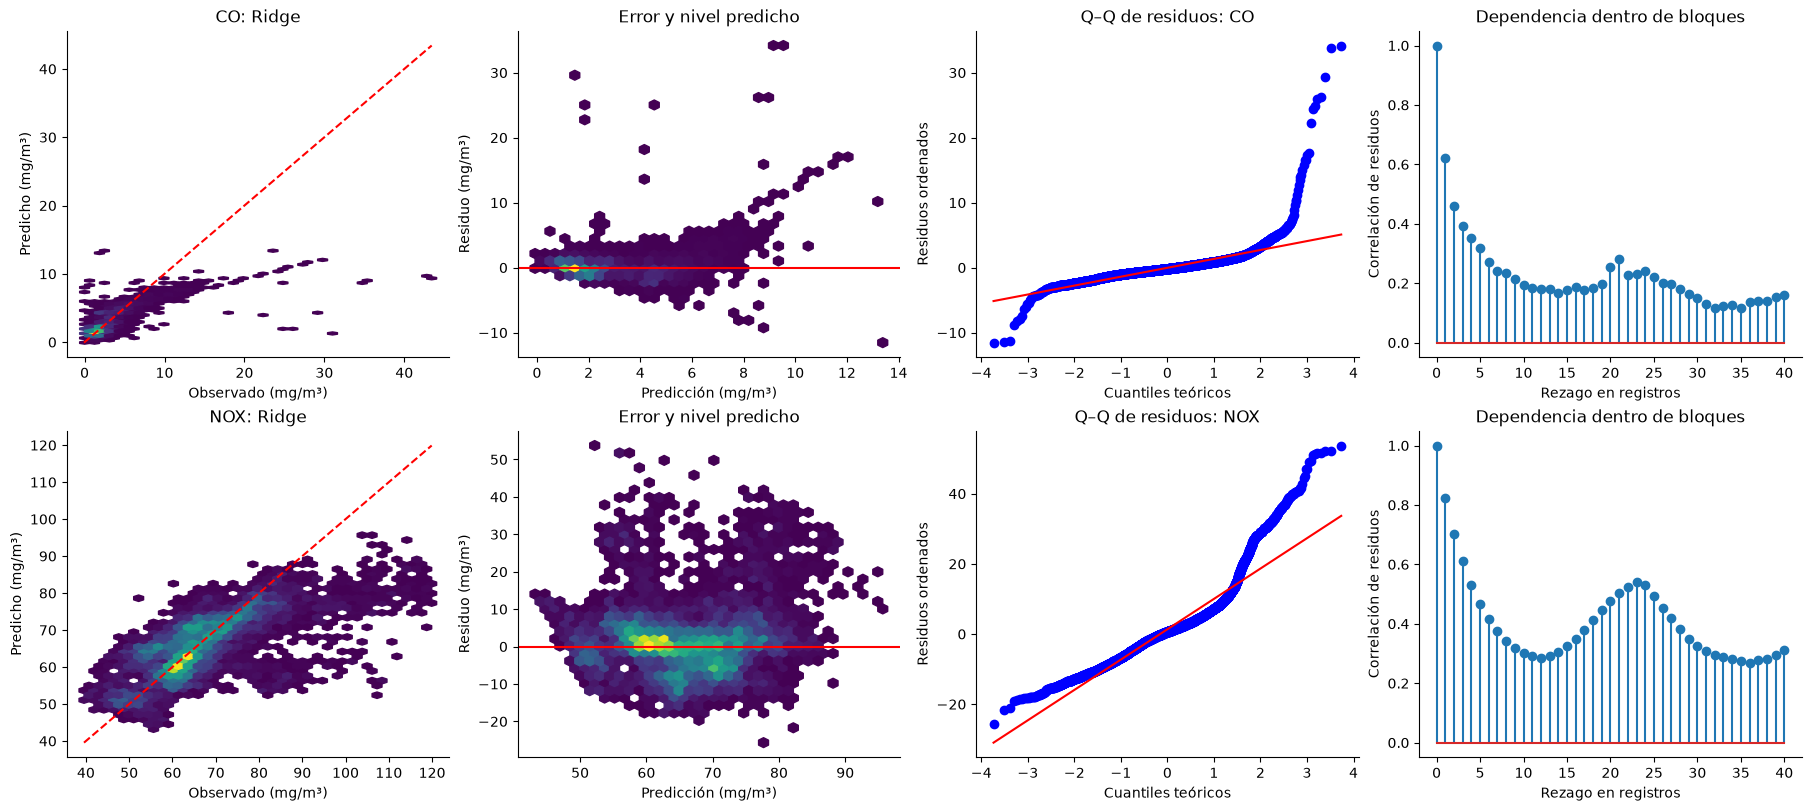

,objetivo,modelo,residuo_medio,normalidad_p,rho_error_abs_pred,p_asociacion
0,CO,Ridge,-0.02560,0.0,0.33755,0.0
1,NOX,Ridge,1.36507,0.0,0.06877,0.0


In [15]:
from block_model import correlacion_intra_bloque
diagnosticos=[]
fig,axes=plt.subplots(2,4,figsize=(18,8),layout='constrained')
for i,t in enumerate(OBJETIVOS):
    nombre=seleccion_final[t]
    y=evaluacion[t].to_numpy();p=predicciones[t,nombre];r=y-p
    axes[i,0].hexbin(y,p,gridsize=35,mincnt=1,cmap='viridis')
    lim=[min(y.min(),p.min()),max(y.max(),p.max())]
    axes[i,0].plot(lim,lim,'r--')
    axes[i,0].set(xlabel='Observado (mg/m³)',ylabel='Predicho (mg/m³)',title=f'{t}: {nombre}')
    axes[i,1].hexbin(p,r,gridsize=35,mincnt=1,cmap='viridis');axes[i,1].axhline(0,color='r')
    axes[i,1].set(xlabel='Predicción (mg/m³)',ylabel='Residuo (mg/m³)',title='Error y nivel predicho')
    stats.probplot(r,dist='norm',plot=axes[i,2])
    axes[i,2].set(title=f'Q–Q de residuos: {t}',xlabel='Cuantiles teóricos',ylabel='Residuos ordenados')
    axes[i,3].stem(np.arange(41),correlacion_intra_bloque(evaluacion,r))
    axes[i,3].set(title='Dependencia dentro de bloques',xlabel='Rezago en registros',ylabel='Correlación de residuos')
    rho,pval=stats.spearmanr(p,np.abs(r))
    diagnosticos.append({'objetivo':t,'modelo':nombre,'residuo_medio':r.mean(),
                         'normalidad_p':stats.normaltest(r).pvalue,
                         'rho_error_abs_pred':rho,'p_asociacion':pval})
plt.show()
diagnosticos=pd.DataFrame(diagnosticos)
display(diagnosticos.round(5))
diagnosticos.to_csv(SALIDA/'diagnostico_residuos_finales.csv',index=False)

### 4.5 Curvas de aprendizaje por bloques

Se incorporan fracciones crecientes de los bloques elegibles de entrenamiento de cada pliegue. Para cada pliegue se utiliza una permutación reproducible de bloques, compartida por ambos objetivos, y se conservan los registros permitidos por los márgenes de exclusión. La validación permanece fija. Los subconjuntos son anidados; el tamaño final de cada entrenamiento se expresa en registros efectivos.

La familia y los hiperparámetros permanecen fijos en los valores seleccionados, de modo que las curvas son diagnósticos condicionados a esa selección. No se utilizan registros de prueba ni se sustituye el modelo final por los estimadores de estas curvas. El promedio de cinco pliegues puede ocultar diferencias entre regímenes.

Al aumentar el entrenamiento medio de aproximadamente 4.269 a 20.962 registros, R² de validación aumenta de 0,504 a 0,539 para CO y de 0,435 a 0,493 para NOx. La brecha de ajuste se reduce, sobre todo para NOx. La evolución no es estrictamente monótona, porque también cambia la composición de bloques incorporados. La mejora moderada con más datos es compatible con limitaciones de la representación lineal, pero no demuestra que una arquitectura más compleja las resuelva.

,objetivo,fraccion,n_train,R2_train,R2_validacion
0,CO,0.2,4268.8,0.5691,0.5042
1,CO,0.4,8431.6,0.5314,0.5259
2,CO,0.6,12647.6,0.5410,0.5317
3,CO,0.8,16860.0,0.5470,0.5332
4,CO,1.0,20961.6,0.5548,0.5390
5,NOX,0.2,4268.8,0.5774,0.4347
6,NOX,0.4,8431.6,0.5581,0.4773
7,NOX,0.6,12647.6,0.5297,0.4866
8,NOX,0.8,16860.0,0.5309,0.4833
9,NOX,1.0,20961.6,0.5251,0.4933


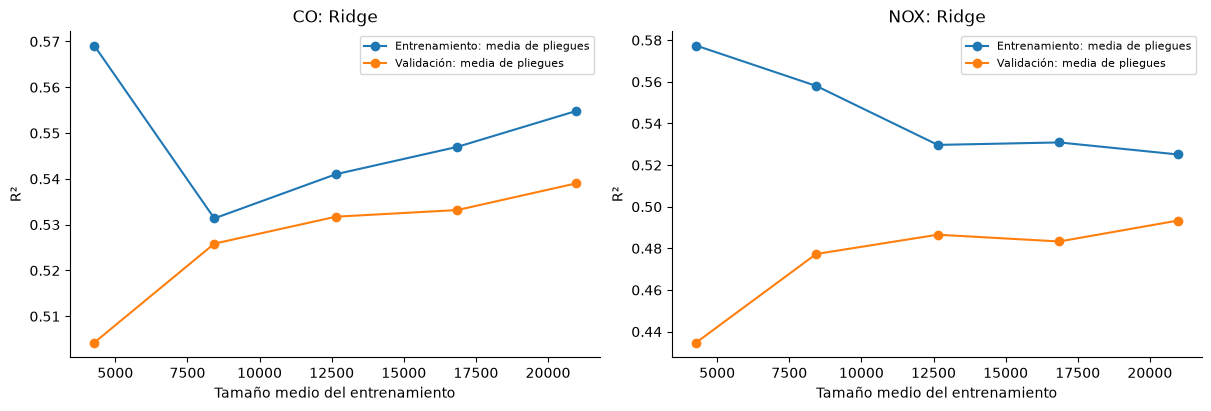

In [16]:
curvas=[]
for numero,(tr,va) in enumerate(splits_bloques,1):
    ids=np.unique(desarrollo.iloc[tr].bloque.to_numpy())
    np.random.default_rng(SEMILLA+numero).shuffle(ids)
    for fraccion in [.2,.4,.6,.8,1]:
        elegidos=ids[:max(1,int(np.ceil(len(ids)*fraccion)))]
        sub=tr[np.isin(desarrollo.iloc[tr].bloque,elegidos)]
        for t in OBJETIVOS:
            m=clone(modelos[t,seleccion_final[t]]).fit(desarrollo.iloc[sub][PREDICTORES],desarrollo.iloc[sub][t])
            curvas.append({'objetivo':t,'fraccion':fraccion,'fold':numero,'n_train':len(sub),
                           'R2_train':r2_score(desarrollo.iloc[sub][t],m.predict(desarrollo.iloc[sub][PREDICTORES])),
                           'R2_validacion':r2_score(desarrollo.iloc[va][t],m.predict(desarrollo.iloc[va][PREDICTORES]))})
curvas=pd.DataFrame(curvas)
promedios=curvas.groupby(['objetivo','fraccion'])[['n_train','R2_train','R2_validacion']].mean().reset_index()
display(promedios.round(4))
fig,axes=plt.subplots(1,2,figsize=(12,4),layout='constrained')
for ax,t in zip(axes,OBJETIVOS):
    g=promedios[promedios.objetivo==t]
    ax.plot(g.n_train,g.R2_train,'o-',label='Entrenamiento: media de pliegues')
    ax.plot(g.n_train,g.R2_validacion,'o-',label='Validación: media de pliegues')
    ax.set(title=f'{t}: {seleccion_final[t]}',xlabel='Tamaño medio del entrenamiento',ylabel='R²')
    ax.legend(fontsize=8)
plt.show()
curvas.to_csv(SALIDA/'curva_aprendizaje.csv',index=False)

### 4.6 Heterogeneidad del desempeño por año

Se examinan exclusivamente los registros de prueba de cada año con los estimadores finales fijos. Ninguno de estos registros interviene en el ajuste. Sin embargo, el entrenamiento sí incluye otros bloques de los mismos años: estas cifras representan desempeño en condiciones contemporáneas reservadas, **no transferencia a un año desconocido**.

El sesgo se define como **predicho menos observado**, con signo contrario al residuo de 4.4. Los intervalos de sesgo remuestrean bloques completos dentro del año correspondiente. El gráfico muestra la media de error de cada bloque reservado en su posición original, sin unir tramos no observados. Los tamaños anuales de prueba difieren y sus métricas tienen distinta incertidumbre.

Un cambio en la distribución marginal de NOx no demuestra cambios en su relación condicional con los sensores. Estos diagnósticos no identifican efectos causales de desgaste, combustible o mantenimiento; tampoco se emplean para reajuste anual posterior a la prueba.

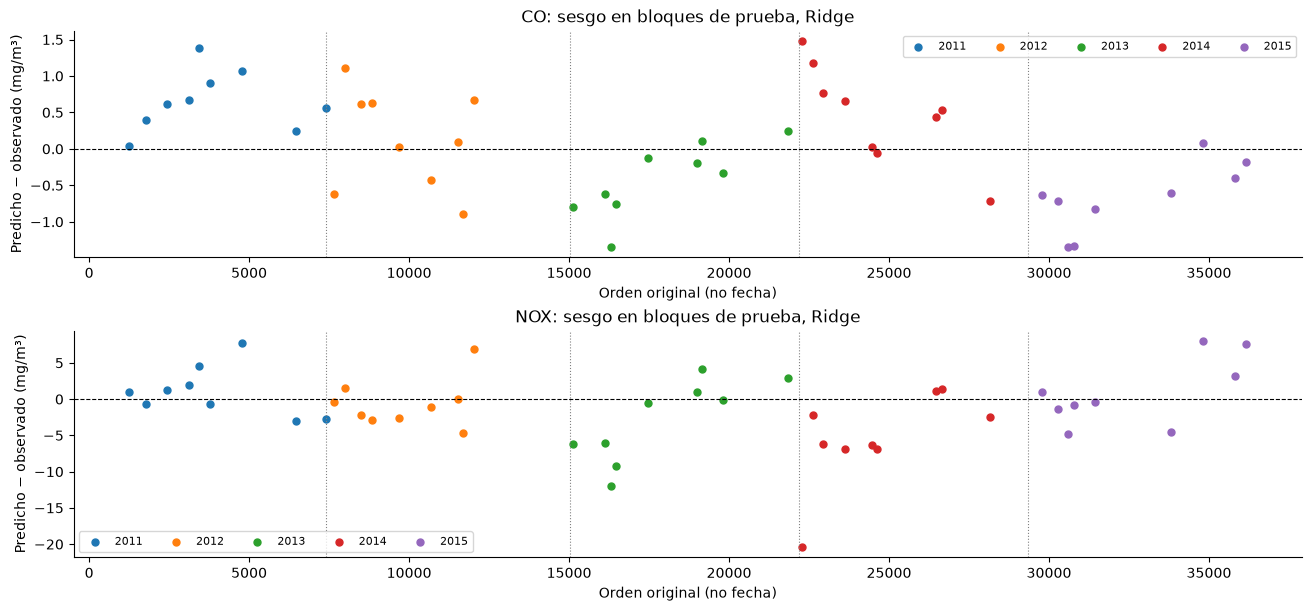

,objetivo,modelo,anio,n_prueba,bloques_prueba,R2,RMSE,MAE,sesgo,MAPE_pct,IC95_sesgo_inf,IC95_sesgo_sup
0,CO,Ridge,2011,1363,9,0.1513,1.6896,1.0438,0.6650,95.4887,0.3788,0.9419
1,CO,Ridge,2012,1512,9,0.4669,1.8309,0.8001,0.1342,108.2457,-0.2845,0.5541
2,CO,Ridge,2013,1512,9,0.7063,1.6188,0.9349,-0.4237,47.1994,-0.7532,-0.1320
3,CO,Ridge,2014,1512,9,0.5038,1.8045,0.9785,0.4774,434.7681,0.0580,0.8754
4,CO,Ridge,2015,1512,9,0.5586,1.4971,0.9499,-0.6620,29.3885,-0.9769,-0.3729
5,NOX,Ridge,2011,1363,9,0.5396,6.8219,4.7509,1.4476,7.3530,-0.5881,3.7316
6,NOX,Ridge,2012,1512,9,0.5123,8.5511,6.1752,-0.5711,9.0049,-2.4594,1.6359
7,NOX,Ridge,2013,1512,9,0.4402,10.5714,7.1579,-2.8883,9.0738,-6.6360,0.3798
8,NOX,Ridge,2014,1512,9,0.0141,11.4479,7.2156,-5.4222,10.0929,-9.8449,-2.0235
9,NOX,Ridge,2015,1512,9,0.6057,7.7795,5.7434,0.8857,9.4110,-1.9416,3.7018


In [17]:
residuos_temporales=[]
fig,axes=plt.subplots(2,1,figsize=(13,6),layout='constrained')
for ax,t in zip(axes,OBJETIVOS):
    auxiliar=evaluacion[['anio','orden_registro','bloque',t]].copy()
    auxiliar['pred']=predicciones[t,seleccion_final[t]]
    auxiliar['sesgo']=auxiliar.pred-auxiliar[t]
    for anio,g in auxiliar.groupby('anio',sort=True):
        b=bootstrap_prueba(g,g[t],g.pred)['sesgo']
        lo,hi=np.quantile(b,[.025,.975])
        residuos_temporales.append({'objetivo':t,'modelo':seleccion_final[t],'anio':anio,
            'n_prueba':len(g),'bloques_prueba':g.bloque.nunique(),**metricas(g[t],g.pred),
            'IC95_sesgo_inf':lo,'IC95_sesgo_sup':hi})
        puntos=g.groupby('bloque').agg(orden=('orden_registro','mean'),sesgo=('sesgo','mean'))
        ax.scatter(puntos.orden,puntos.sesgo,label=str(anio),s=25)
    ax.axhline(0,color='black',ls='--',lw=.8)
    for anio in range(2012,2016):
        ax.axvline(datos.loc[datos.anio==anio,'orden_registro'].min(),color='grey',ls=':',lw=.8)
    ax.set(title=f'{t}: sesgo en bloques de prueba, {seleccion_final[t]}',
           xlabel='Orden original (no fecha)',ylabel='Predicho − observado (mg/m³)')
    ax.legend(ncol=5,fontsize=8)
plt.show()
residuos_temporales=pd.DataFrame(residuos_temporales)
display(residuos_temporales.round(4))
residuos_temporales.to_csv(SALIDA/'desempeno_prueba_por_anio.csv',index=False)

### 4.7 Artefacto final y uso posterior

El modelo final integra dos regresores independientes, seleccionados por el menor MSE medio de validación por bloques: **Ridge para CO y Ridge para NOx**. No constituye una arquitectura multitarea nueva. Ambos incluyen las transformaciones ajustadas con los 27.570 registros elegibles de desarrollo, sin incorporar la prueba ni sus márgenes de exclusión.

El artefacto conserva los estimadores, el orden y las unidades de los nueve sensores, los hiperparámetros, el diseño de validación y las versiones de bibliotecas. Se verifica que las predicciones recargadas coincidan con las utilizadas en la evaluación. La aplicación exige sensores contemporáneos con definiciones y unidades compatibles, valores numéricos finitos y disponibilidad independiente del analizador de gases. CO y NOx no se requieren como entradas.

Las predicciones negativas se conservan y se documentan, sin recorte posterior. La reutilización computacional no equivale a certificación industrial o regulatoria. La aplicación a periodos o plantas no representados requiere validación externa y seguimiento de calibración. Los archivos serializados deben proceder de fuentes confiables.

In [18]:
artefacto_final=joblib.load(experimento['ruta_modelo'])
predicciones_finales=predecir_final(artefacto_final,evaluacion[PREDICTORES])
for t in OBJETIVOS:
    assert artefacto_final['estimadores'][t].regressor_[0].n_samples_seen_==len(desarrollo)
    assert artefacto_final['estimadores'][t].transformer_.n_samples_seen_==len(desarrollo)
    np.testing.assert_allclose(predicciones_finales[t],predicciones[t,seleccion_final[t]])
display(pd.DataFrame([{'objetivo':t,'familia':seleccion_final[t],
    'hiperparametros':str(artefacto_final['hiperparametros'][t]),
    'anios_representados':'2011–2015','n_ajuste':artefacto_final['n_ajuste'],
    'bloque_registros':168,'margen_registros':24,'unidad':'mg/m³'} for t in OBJETIVOS]))
display(finales[['objetivo','modelo','R2_test','RMSE_test','MAE_test','sesgo_test','negativos_test']].round(4))

,objetivo,familia,hiperparametros,anios_representados,n_ajuste,bloque_registros,margen_registros,unidad
0,CO,Ridge,{'regressor__ridge__alpha': 1},2011–2015,27570,168,24,mg/m³
1,NOX,Ridge,{'regressor__ridge__alpha': 1},2011–2015,27570,168,24,mg/m³


,objetivo,modelo,R2_test,RMSE_test,MAE_test,sesgo_test,negativos_test
1,CO,Ridge,0.5638,1.6927,0.9394,0.0256,3
4,NOX,Ridge,0.4741,9.2392,6.2379,-1.3651,0


### 4.8 Coeficientes e interpretación de Ridge

Se examinan **los dos modelos finales ya guardados**, sin volver a ajustarlos. La tabla presenta el coeficiente estandarizado y dos conversiones: cambio de concentración por una desviación estándar del sensor de desarrollo y cambio por una unidad física original del sensor. La comparación de magnitudes estandarizadas facilita la lectura, pero no constituye una clasificación causal de importancia.

Si b es el coeficiente con sensor y respuesta estandarizados, el coeficiente físico es b × SD(respuesta) / SD(sensor). El cambio por una desviación estándar del sensor es b × SD(respuesta), en mg/m³. El intercepto original se obtiene deshaciendo también el centrado. Se verifica que esta expresión reproduce las predicciones del artefacto sobre desarrollo.

Un signo positivo indica mayor concentración predicha al aumentar ese sensor, **manteniendo constantes los otros ocho**; un signo negativo indica menor concentración. Estos contrastes son condicionados al modelo y podrían representar combinaciones de sensores poco frecuentes o físicamente inviables. La multicolinealidad documentada mediante VIF puede cambiar signos y magnitudes respecto a las correlaciones marginales. Ridge estabiliza el ajuste, pero no convierte los coeficientes en efectos causales ni permite atribuirles una significación estadística clásica sin un procedimiento adicional.

El intercepto es un término algebraico: no se interpreta como emisión observada cuando todos los sensores valen cero. No se estiman intervalos de confianza ni valores p para los coeficientes en esta sección.


,objetivo,sensor,unidad_sensor,media_sensor_desarrollo,SD_sensor_desarrollo,coeficiente_estandarizado,cambio_mg_m3_por_1_SD_sensor,cambio_mg_m3_por_unidad_sensor
0,CO,AT,degC,18.106375,7.267049,-0.112447,-0.243661,-0.033530
1,CO,AP,mbar,1012.967323,6.502451,-0.012917,-0.027990,-0.004305
2,CO,AH,%,77.503509,14.569849,-0.037940,-0.082211,-0.005643
3,CO,AFDP,mbar,3.937783,0.770769,-0.022123,-0.047938,-0.062195
4,CO,GTEP,mbar,25.678768,4.211236,0.146704,0.317891,0.075486
5,CO,TIT,degC,1082.136852,17.408576,-0.625446,-1.355272,-0.077851
6,CO,TAT,degC,546.100834,6.758251,-0.234674,-0.508512,-0.075243
7,CO,TEY,MWh,133.888254,15.647597,-1.057601,-2.291706,-0.146457
8,CO,CDP,mbar,12.094587,1.094347,0.754971,1.635940,1.494901
9,NOX,AT,degC,18.106375,7.267049,-1.121518,-12.663356,-1.742572


,objetivo,intercepto_mg_m3,n_ajuste
0,CO,132.897082,27570
1,NOX,-54.165833,27570


**CO:** TEY tiene el mayor coeficiente absoluto por una desviación estándar. Aumentar ese sensor 15.648 MWh, manteniendo los demás constantes, cambia la concentración predicha en -2.292 mg/m³. En unidades originales, el coeficiente es -0.146457 mg/m³ por MWh. La interpretación es condicional y no causal.

El R² OOF de TEY como único sensor es 0.328. Su coeficiente condicionado y su desempeño individual responden a preguntas distintas: el primero depende de las correlaciones con los demás sensores y de la regularización; el segundo mide una asociación lineal marginal. Una magnitud grande no demuestra importancia causal.

**NOX:** TEY tiene el mayor coeficiente absoluto por una desviación estándar. Aumentar ese sensor 15.648 MWh, manteniendo los demás constantes, cambia la concentración predicha en -30.248 mg/m³. En unidades originales, el coeficiente es -1.933061 mg/m³ por MWh. La interpretación es condicional y no causal.

El R² OOF de TEY como único sensor es -0.007. Su coeficiente condicionado y su desempeño individual responden a preguntas distintas: el primero depende de las correlaciones con los demás sensores y de la regularización; el segundo mide una asociación lineal marginal. Una magnitud grande no demuestra importancia causal.

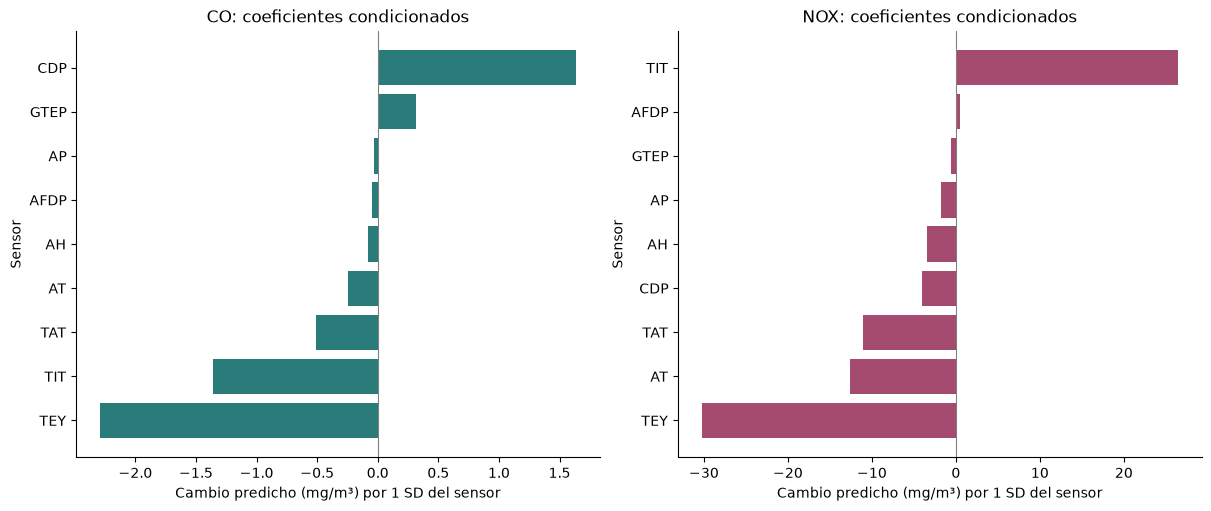

In [19]:
from auditoria_sensores import interpretar_coeficientes
coeficientes,interceptos=interpretar_coeficientes(artefacto_final,desarrollo[PREDICTORES])
display(coeficientes.round(6))
display(interceptos.round(6))
coeficientes.to_csv(SALIDA/'coeficientes_ridge_interpretacion.csv',index=False)
interceptos.to_csv(SALIDA/'interceptos_ridge_unidades_originales.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,5),layout='constrained')
for ax,t,color in zip(axes,OBJETIVOS,['#297c79','#a44b6f']):
    tabla=coeficientes[coeficientes.objetivo==t].sort_values('cambio_mg_m3_por_1_SD_sensor')
    ax.barh(tabla.sensor,tabla.cambio_mg_m3_por_1_SD_sensor,color=color)
    ax.axvline(0,color='grey',lw=.8)
    ax.set(title=f'{t}: coeficientes condicionados',
           xlabel='Cambio predicho (mg/m³) por 1 SD del sensor',ylabel='Sensor')
    mayor=tabla.loc[tabla.cambio_mg_m3_por_1_SD_sensor.abs().idxmax()]
    cambio=mayor.cambio_mg_m3_por_1_SD_sensor
    display(Markdown(f'**{t}:** {mayor.sensor} tiene el mayor coeficiente absoluto por una '
        f'desviación estándar. Aumentar ese sensor {mayor.SD_sensor_desarrollo:.3f} '
        f'{mayor.unidad_sensor}, manteniendo los demás constantes, cambia la concentración '
        f'predicha en {cambio:+.3f} mg/m³. En unidades originales, el coeficiente es '
        f'{mayor.cambio_mg_m3_por_unidad_sensor:+.6f} mg/m³ por {mayor.unidad_sensor}. '
        'La interpretación es condicional y no causal.'))
    individual=auditoria_univariada.loc[(auditoria_univariada.objetivo==t)&
        (auditoria_univariada.sensor==mayor.sensor)].iloc[0]
    display(Markdown(f'El R² OOF de {mayor.sensor} como único sensor es '
        f'{individual.R2_OOF:.3f}. Su coeficiente condicionado y su desempeño individual '
        'responden a preguntas distintas: el primero depende de las correlaciones con '
        'los demás sensores y de la regularización; el segundo mide una asociación '
        'lineal marginal. Una magnitud grande no demuestra importancia causal.'))
plt.show()


## 5. Estado del arte y delimitación de la propuesta original

### 5.1 Estrategia de búsqueda y comparabilidad

Búsqueda exploratoria realizada el **3 de octubre de 2026**, no una revisión sistemática. Consultas: `gas turbine CO NOx emissions dataset Kaya Tufekci performance`, `36733 gas turbine R2`, título del conjunto y `gas turbine emissions machine learning`. Se priorizan editoriales, repositorios institucionales, congresos y proyectos con código. Se distingue **mismo UCI 551**, datos industriales distintos y métodos fuera del alcance. Cuando no se verificó una cifra primaria, se indica expresamente y no se estima.

La revisión tiene dos objetivos: identificar **comparadores ya publicados** y delimitar una **propuesta propia no identificada en la literatura revisada sobre esta tarea**. Ejecutar un algoritmo conocido con otros hiperparámetros no constituye por sí solo una contribución original. Tampoco la ausencia en estos 50 registros demuestra que una técnica nunca se haya utilizado: se requiere búsqueda dirigida y lectura de trabajos próximos antes de afirmar novedad.

Las particiones, la normalización del objetivo, el filtrado de extremos y el uso de señales históricas modifican el problema evaluado. En consecuencia, no se establece una clasificación global a partir de métricas obtenidas bajo protocolos incompatibles. Los resultados bibliográficos corresponden a cifras publicadas, no a reproducciones experimentales de este estudio. Los modelos de referencia no constituyen la contribución original; su formulación específica y validación de novedad siguen pendientes.

### 5.2 Estudios y proyectos

| Fuente | Datos y modelos | Desempeño verificado | Advertencia |
|---|---|---|---|
| Kaya, Tüfekci y Uzun (2019), [artículo original](https://journals.tubitak.gov.tr/elektrik/vol27/iss6/53/) | UCI 551; Extreme Learning Machine (ELM) | Cifra no verificada en el texto completo accesible durante esta búsqueda | ELM es neuronal; se cita como origen, no se implementa |
| Wood (2023), [Fuel, 127722](https://doi.org/10.1016/j.fuel.2023.127722) | Mismo conjunto; 12 modelos; KNN y XGBoost destacados | Mejor KNN: MAE CO 0,8458; NOx 5,1234 mg/m³, según resumen editorial | Incluye análisis/corrección de desplazamientos temporales; detalles completos no auditados. No permite comparación directa con las métricas de este estudio |
| Sinap (2025), [doi:10.38016/jista.1566965](https://dergipark.org.tr/en/download/article-file/4286940) | UCI; LR, SVR-RBF, DT, RF, ET, KNN, Voting y Stacking | Resultados por modelo en tabla siguiente | División 80/20, semilla 42; protocolo de registros individuales, distinto de la separación por bloques. Se transcribe escenario crudo, sin eliminación de extremos |
| Jhinaoui et al. (2024), [GPPS-TC-2024-0154](https://gpps.global/wp-content/uploads/2024/09/GPPS-TC-2024_paper_154.pdf) | UCI; CatBoost + Catch22, TapNet | RMSE CO/NOx: CatBoost 1,48/5,63; TapNet 1,70/7,55 mg/m³; prueba 2015 | Entrenamiento 2011–2013, validación 2014, prueba 2015. Catch22 incorpora historia y TapNet es profundo; se citan como antecedentes, no como propuestas originales |
| Zeinalipour et al. (2025), [arXiv:2501.17865v1](https://arxiv.org/html/2501.17865v1) | **Otro conjunto**, 113.675 registros y 13 variables; modelos lineales, SVM, DT, XGBoost, KNN y redes | RMSE normalizado CO/NOx: XGBoost 0,02158/0,02509; KNN 0,02033/0,01741 | Preprint; no son mg/m³ ni resultados del UCI. No trasladar estas cifras al proyecto |
| mowen18, [proyecto con código](https://github.com/mowen18/gas-turbines-emissions-ml) (consulta 2026) | UCI; Ridge, RF y SVR-RBF | RF, prueba 2015: R² CO 0,4719, NOx −0,0212; RMSE 1,624 y 11,249 mg/m³ | Proyecto no revisado por pares. Selección 2012–2014; SVR limitado a 5.000 filas. Resultados declarados, no ejecutados aquí |

El resumen editorial de Wood puede consultarse en [ScienceDirect](https://www.sciencedirect.com/science/article/pii/S0016236123003356). Los enlaces DOI y de artículo permiten identificar la fuente aunque el texto completo no esté disponible.

### 5.3 Lista de modelos con resultados del mismo conjunto

Sinap (2025), **tablas 4 y 5, escenario Raw**. Orden de cifras: CO y NOx. Son resultados publicados con división 80/20, no nuestra validación por bloques con margen de exclusión.

| Modelo | R² CO | RMSE CO (mg/m³) | R² NOx | RMSE NOx (mg/m³) |
|---|---:|---:|---:|---:|
| Regresión lineal | 0,5566 | 1,5526 | 0,4946 | 8,1832 |
| SVR RBF | 0,6755 | 1,3282 | 0,7574 | 5,6698 |
| Árbol de decisión | 0,5081 | 1,6354 | 0,7367 | 5,9059 |
| Random Forest | 0,7649 | 1,1306 | 0,8765 | 4,0443 |
| Extra Trees | 0,7990 | 1,0453 | 0,8908 | 3,8037 |
| KNN | 0,7630 | 1,1350 | 0,8549 | 4,3846 |
| Voting (GB, LightGBM, CatBoost) | 0,7631 | 1,1349 | 0,8575 | 4,3447 |
| Stacking (anteriores + XGBoost) | 0,8026 | 1,0359 | 0,8942 | 3,7430 |

Se omiten los resultados de escenarios con filtrado de observaciones, puesto que el cambio de población dificulta su comparabilidad. La evidencia sugiere la utilidad de representar interacciones no lineales, pero no demuestra que las métricas publicadas puedan alcanzarse bajo el diseño por bloques adoptado ni trasladarse a periodos futuros.

### 5.4 Comparadores, no propuestas originales

RF, Extra Trees, XGBoost, LightGBM, CatBoost, KNN, SVR-RBF, Cubist, regresión simbólica y Deep Forest cuentan con antecedentes en la literatura revisada. GAM también aparece como componente del ensamble de Pachauri (2024). Estas familias constituyen comparadores, no una contribución original por sí mismas. Los ensambles genéricos y la segmentación por régimen presentan antecedentes próximos en Sinap, Faqih y Winarto. Catch22, los predictores rezagados y las redes neuronales quedan fuera del alcance tabular contemporáneo del estudio.

La búsqueda dirigida adicional encontró **NGBoost aplicado a NOx** en un combustor RQL de turbina, con 92 configuraciones simuladas: [Energy (2023), doi:10.1016/j.energy.2023.127227](https://www.sciencedirect.com/science/article/abs/pii/S0360544223006217). No es UCI, pero impide presentarlo como un algoritmo nunca usado en emisiones de turbinas. Este antecedente está fuera del TXT original. Un [benchmark público de regresiones de árboles](https://github.com/szcf-weiya/benchmark.tree.regressions) también enumera GasTurbine junto con BART, XBART y MARS; su ejecución específica no se auditó, por lo que esas familias no se califican automáticamente de inéditas.

## 6. Discusión y conclusiones

La interpretación se sustenta en bloques de 168 registros, cinco pliegues de validación y un margen de exclusión de 24 registros. Desarrollo y prueba representan 2011–2015. Los estimadores finales se seleccionan por el menor MSE medio de validación, no por la clasificación de resultados de prueba. Se mantienen separados CO y NOx por sus diferencias de escala y estabilidad. No se confunde concentración con caudal másico de emisiones, ajuste aparente con generalización, ni estimación en condiciones representadas con extrapolación temporal.

In [20]:
for t in OBJETIVOS:
    final=finales.set_index('objetivo').loc[t]
    r=resumen_cv[(resumen_cv.objetivo==t)&(resumen_cv.modelo==seleccion_final[t])].iloc[0]
    d=resultados[(resultados.objetivo==t)&(resultados.modelo=='Media')].iloc[0]
    reduccion=100*(1-final.RMSE_test/d.RMSE_test)
    display(Markdown(f'**{t}, {seleccion_final[t]}:** R² de entrenamiento {r.R2_train:.3f}, '
                     f'OOF {r.R2_OOF:.3f} y prueba {final.R2_test:.3f}; '
                     f'RMSE de prueba {final.RMSE_test:.3f} mg/m³, MAE {final.MAE_test:.3f} mg/m³ '
                     f'y sesgo {final.sesgo_test:.3f} mg/m³. '
                     f'El RMSE disminuye {reduccion:.1f}% respecto de la media de entrenamiento.'))

**CO, Ridge:** R² de entrenamiento 0.554, OOF 0.543 y prueba 0.564; RMSE de prueba 1.693 mg/m³, MAE 0.939 mg/m³ y sesgo 0.026 mg/m³. El RMSE disminuye 34.2% respecto de la media de entrenamiento.

**NOX, Ridge:** R² de entrenamiento 0.525, OOF 0.504 y prueba 0.474; RMSE de prueba 9.239 mg/m³, MAE 6.238 mg/m³ y sesgo -1.365 mg/m³. El RMSE disminuye 28.7% respecto de la media de entrenamiento.

**Conclusiones del modelo final.** Ridge es seleccionado para ambas emisiones por su MSE de validación. En prueba, obtiene **R² = 0,564 y RMSE = 1,693 mg/m³ para CO**, y **R² = 0,474 y RMSE = 9,239 mg/m³ para NOx**. Ambos superan la predicción constante, pero su capacidad explicativa es moderada y deja margen para evaluar representaciones no lineales. La diferencia entre R² de entrenamiento y el promedio de validación es pequeña para CO (0,554 frente a 0,539) y mayor para NOx (0,525 frente a 0,493), sin evidencia de una brecha extrema. El desempeño de NOx es más sensible a los bloques evaluados; no puede atribuirse exclusivamente a sobreajuste. Los sesgos globales son aproximadamente +0,026 mg/m³ para CO y −1,365 mg/m³ para NOx. Las predicciones negativas y los errores por año se documentan como limitaciones de uso.

El artefacto guardado constituye una **línea base reproducible y reutilizable**, no la contribución original planteada en la revisión. La representación de relaciones no lineales y la incorporación de factores operativos relevantes podrían mejorar el desempeño, pero esa hipótesis requiere evaluación sin modificar el modelo ni seleccionar hiperparámetros a partir de la prueba. La reutilización exige mantener las definiciones y unidades de sensores, verificar calibración y validar externamente antes de decisiones industriales o regulatorias.

**Alcance y limitaciones.** El tamaño supera 20.000 filas, pero existe una sola turbina y dependencia serial. Hay riesgo de cambios de sensor, combustible, mantenimiento o régimen no observados. La falta de timestamps impide completar análisis de calendario, frecuencia, huecos y estacionalidad. Las secciones ADF/KPSS no sustituyen esa documentación. Los intervalos bootstrap son condicionales y la prueba histórica sobre datos conocidos no constituye evidencia prospectiva intacta.

**Ética y uso.** No se observan datos personales ni coordenadas; el riesgo principal es industrial: sustituir medición certificada por estimaciones no validadas, ignorar extremos o interpretar correlación como control causal. Se atribuye la fuente conforme a CC BY 4.0. No se propone usar este notebook para decisiones regulatorias o automáticas de operación.


## 7. Reproducibilidad y cobertura del entregable

| Requisito | Cobertura |
|---|---|
| Problema, fuente, licencia, diccionario, n/p y entidades | Secciones 1–2 |
| Faltantes, duplicados/casi duplicados, extremos y coherencia | 3.1–3.2 |
| EDA uni, bi y multivariado con interpretación | 3.2–3.5 |
| Fuga y disponibilidad de variables | 3.4 y 4.2 |
| Dependencia, cambios de distribución, tendencia y partición por bloques | 2, 3.6; 3.7 (distribuciones de 2011–2015) y 4.6 (desempeño anual) |
| STL, calendario, frecuencia, huecos y coordenadas | No identificables con la información disponible |
| Pipeline, Dummy y SVR lineal | 4.1–4.2; validación por bloques y ajuste final |
| RMSE, MAPE, R², incertidumbre, residuos y aprendizaje | 4.2–4.6; artefacto final reutilizable en 4.7 |
| Interpretación de coeficientes | 4.8; escalas, unidades y cautelas por multicolinealidad |
| Evidencia científica y modelos futuros | 5 |
| Informe Jupyter Book, datos, dependencias y semillas | Notebook ejecutado, `_config.yml`, `_toc.yml`, `data/`, `requirements_notebook.txt`; semilla 42 |

La reproducibilidad se sustenta en los cinco archivos originales de UCI, la conservación del orden de observación, los cinco pliegues por bloques, el margen de exclusión y la semilla 42. Se documentan versiones, configuraciones seleccionadas, predicciones OOF y predicciones de prueba. El material suplementario contiene métricas por pliegue y año de prueba, entrenamiento final, evaluación por bloques, incertidumbre de evaluación y el artefacto final con metadatos de sensores y bibliotecas.

### Referencias

- UCI (2019). *Gas Turbine CO and NOx Emission Data Set*. [doi:10.24432/C5WC95](https://doi.org/10.24432/C5WC95).
- Kaya, H., Tüfekci, P. y Uzun, E. (2019). *Predicting CO and NOx emissions from gas turbines: novel data and a benchmark PEMS*. Turkish Journal of Electrical Engineering and Computer Sciences, 27, 4783–4796. [doi:10.3906/elk-1807-87](https://doi.org/10.3906/elk-1807-87).
- Wood, D. A. (2023). *Long-term atmospheric pollutant emissions from a combined cycle gas turbine: Trend monitoring and prediction applying machine learning*. Fuel, 343, 127722. [doi:10.1016/j.fuel.2023.127722](https://doi.org/10.1016/j.fuel.2023.127722).
- Sinap, V. (2025). *Outliers Treatment for Improved Prediction of CO and NOx Emissions from Gas Turbines Using Ensemble Regressor Approaches*. Journal of Intelligent Systems: Theory and Applications, 8(1), 63–83. [doi:10.38016/jista.1566965](https://doi.org/10.38016/jista.1566965).
- Jhinaoui, A., Pieyre, A., Malkogianni, A., Azamar, H. y Tsoutsanis, E. (2024). *Attentional Neural Network for the Prediction of Gas Turbine CO and NOx Emission*. GPPS-TC-2024-0154. [Artículo](https://gpps.global/wp-content/uploads/2024/09/GPPS-TC-2024_paper_154.pdf).
- Zeinalipour, K., Barriere, L., Ghelardi, D. y Gori, M. (2025). *Application of Machine Learning Models for Carbon Monoxide and Nitrogen Oxides Emission Prediction in Gas Turbines*. Preprint. [arXiv:2501.17865v1](https://arxiv.org/html/2501.17865v1).
- mowen18 (s.f.). *Gas Turbine CO and NOx Emissions Modeling*. Proyecto de código, consulta 03/10/2026. [GitHub](https://github.com/mowen18/gas-turbines-emissions-ml).

## 8. Ampliación bibliográfica y fundamento de la partición

### 8.1. Protocolo adoptado

El protocolo principal reserva aproximadamente el 20% de bloques de **168 registros** para prueba, estratificando por año, y utiliza **cinco pliegues de bloques** en el desarrollo. Un margen de **24 registros** alrededor de la prueba y de cada validación reduce la proximidad entre ajuste y evaluación. Desarrollo y prueba representan los cinco años; las familias e hiperparámetros se seleccionan únicamente por el MSE de validación. Año, posición y emisiones rezagadas no son predictores.

La heterogeneidad anual documentada motiva distinguir dos preguntas. Leave-One-Year-Out (LOYO) evalúa transferencia hacia un año no representado; puede ser pertinente para despliegue en periodos desconocidos, pero no corresponde a la pregunta principal de estimación contemporánea en las condiciones representadas. Las diferencias de distribución no hacen inválido ese diseño. La partición por bloques tampoco demuestra generalización futura ni garantiza independencia. El criterio de adopción es la correspondencia con el objetivo, no obtener una puntuación mayor.

### 8.2. Protocolos encontrados en la literatura

| Fuente | Validacion documentada | Relación con el protocolo por bloques |
|---|---|---|
| [UCI / Kaya et al.](https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set) | El repositorio recomienda entrenar primeros tres anos y probar ultimos dos | Su recomendación evalúa periodos no representados; el diseño principal mezcla bloques de los cinco años para otra población de generalización |
| [Wood (2023)](https://doi.org/10.1016/j.fuel.2023.127722) | Multi-K-fold y evaluacion en dos anos separados; estudia desplazamientos temporales | Antecedente de transferencia cronológica; no se replica su corrección temporal |
| [Jhinaoui et al. (2024), metodologia p. 4](https://gpps.global/wp-content/uploads/2024/09/GPPS-TC-2024_paper_154.pdf) | **2011-2013 entrenamiento (22.191), 2014 validacion (7.158), 2015 prueba (7.384)**; aproximadamente 60,4 / 19,5 / 20,1% | Su prueba comprende un año completo no representado; no equivale a reservar bloques de los cinco años |
| [Sinap (2025), secciones 2.5 y 2.7](https://dergipark.org.tr/en/download/article-file/4286940) | 80% entrenamiento / 20% prueba; semilla 42; optimizacion bayesiana; declara SKCV con k=10 | Proporción similar de prueba, pero sin separación por bloques verificada; la estratificación continua y su relación con el holdout requieren aclaración |
| [Coelho et al. (2024)](https://doi.org/10.1016/j.fuel.2023.129366), resumen del TXT | Randomized Search con CV de cinco pliegues; medias de entrenamiento y validacion | Antecedente de selección mediante CV; el resumen no verifica agrupación por año ni orden cronológico |
| [Naghibi (2024)](https://doi.org/10.1016/j.engappai.2024.109318), resumen del TXT | Entrenamiento/validacion 2011-2014 y evaluacion 2015 | Referencia de corte anual para potencia, no emisiones; ni su tarea ni su partición equivalen a las del proyecto |
| [Dirik (2022)](https://doi.org/10.1016/j.fuel.2022.124037), resumen del TXT | Compara distintas proporciones entrenamiento/prueba; orden y fracciones exactas no verificadas | No se atribuye una partición aleatoria ni una proporción exacta no comprobada |

La literatura con protocolos documentados distingue **validación cruzada durante el desarrollo** de **un conjunto de validación separado de entrenamiento y prueba**. En un subconjunto descriptivo de cinco estudios de emisiones con información explícita (Wood, Sinap, Coelho, Jhinaoui y Dirik), tres reportan validación cruzada: Multi-K-fold, diez y cinco pliegues, respectivamente. Wood y Jhinaoui describen evaluación en periodos separados; Sinap declara una partición 80/20 y Dirik compara distintas proporciones. Estas categorías se solapan. Jhinaoui es el único estudio de este subconjunto en el que se verifican tres periodos fijos completos de entrenamiento, validación y prueba; la información disponible no permite descartar ese esquema en los demás trabajos.

Este conteo **no es una tasa de los 50 registros ni una estimación de toda la literatura**: los cinco se seleccionaron precisamente porque documentan el protocolo. No hay evidencia suficiente para declarar 80/20 como la partición predominante. El referente más claro para separar tres conjuntos en UCI es 2011-2013 / 2014 / 2015; la CV de cinco o diez pliegues también es recurrente, sin que todos los trabajos aclaren si mezcla años. Una CV aleatoria no equivale a validación cronológica ni demuestra transferencia a operación posterior.

### 8.3. Caracterización del corpus bibliográfico

El corpus complementario comprende **50 registros bibliográficos exportados de Web of Science**. Se identifican título, autores, año, DOI, publicación y resumen mediante los campos TI, AU, PY, DI, SO y AB. El catálogo completo forma parte del material suplementario. La selección no constituye una revisión sistemática exhaustiva, puesto que se desconoce la consulta original y su cobertura. Salvo indicación de acceso al texto completo, las cifras proceden de los **resúmenes del corpus**, no de reproducciones experimentales. Se distinguen tareas, unidades y resultados de entrenamiento o validación; la información no verificable se señala explícitamente.

| Estudio y enlace | Modelos y resultado disponible | Pertinencia y cautela |
|---|---|---|
| [Kochueva y Nikolskii, 2021](https://doi.org/10.3390/computation9120139) | Regresion simbolica + algoritmo genetico; R2 NOx 0,83 y CO 0,89; clasificador difuso adicional | UCI confirmado en resumen. Orden de validacion y subconjunto de esas cifras pendientes; opcion interpretable no neuronal |
| [Coelho, Ayala y Mariani, 2024](https://doi.org/10.1016/j.fuel.2023.129366) | Ridge, Lasso, KNN, Cubist, RF, LightGBM, CatBoost y Deep Forest; PCA/t-SNE/UMAP/PHATE. DFR: **validacion** CO R2 0,5355 / RMSE 1,4508; NOx R2 0,4737 / RMSE 7,6528 | Entrenamiento R2 0,9647 y 0,9866 respectivamente, no confundir con generalizacion. Deep Forest es ensamble de arboles, no deep learning neuronal. Identidad completa del dataset/unidades y orden de CV por verificar |
| [Wu et al., 2023](https://doi.org/10.1002/ente.202300041) | RF, XGBoost, DNN y LSTM con seleccion/optimizacion; mejoras declaradas 18-67%; RF destacado por costo y precision | Interes para RF y XGBoost; sin metricas absolutas ni particion exacta en resumen |
| [Chen y Pu, 2024](https://doi.org/10.1007/s12206-024-0245-3) | XGBoost y GWO-XGBoost, sensibilidad Sobol; resumen atribuye a XGBoost R2 0,928, RMSE 0,278, MSE 0,077 | Escala/unidades, dataset y protocolo pendientes. No comparar RMSE directamente con mg/m3 |
| [Hoque et al., 2024](https://doi.org/10.1115/1.4065200) | RF, XGBoost, CatBoost: precision reportada 91,68%, 91,54%, 92,76% | No convertir esos porcentajes en R2 sin verificar la definicion de precision |
| [Aslan, 2024](https://doi.org/10.24425/bpasts.2024.151956) | AdaBoost, XGBoost, KNN, lineal y RF; busqueda aleatoria. AdaBoost precision 99,97% y MSE 2,17 **en entrenamiento** | No constituye evidencia de desempeno de prueba ni de R2 cercano a 1 |
| [Faqih, Omar e Ibrahim, 2023](https://doi.org/10.3390/s23083863) | XGBoost + KMeans; R2 NOx 0,9309, CO 0,7109, temperatura 0,9999 | Datos de planta real, identidad UCI no confirmada. Motiva investigar regimenes operativos; division exacta pendiente |
| [Winarto et al., 2026](https://doi.org/10.1016/j.eij.2026.101041) | Stacking XGBoost/DT/LightGBM + ElasticNet separado por arranque, estacionario y transitorio; R2 validacion 0,39-0,95 / 0,88-0,97 / 0,73-0,98 | Otros contaminantes CO, CO2, SO2 y **NO**, no identificar NO con NOx. Rangos abarcan contaminantes, no una metrica unica de NOx |
| [Potts, Hackney y Leontidis, 2023](https://doi.org/10.3390/make5030055) | XGBoost, SAINT y cinetica quimica; texto editorial identifica XGBoost como mejor modelo tabular | Banco Siemens Energy comercial, no UCI. Sin cifra/protocolo verificado en esta ampliacion; SAINT excluido por neuronal |
| [Dirik, 2022](https://doi.org/10.1016/j.fuel.2022.124037) | ANFIS-GA NOx: R2 0,79933-0,90363 entre proporciones; minimo RMSE prueba 5,1571, MAPE 5,3695% | Neurodifuso: antecedente, no candidato implementado. El rango R2 no se debe asociar automaticamente al minimo RMSE |
| [Roy et al., 2026](https://doi.org/10.1007/s10668-025-07209-w) | MCNN-BiLSTM con atencion: R2 NOx 0,881 y CO 0,801 | Deep learning excluido; identidad/protocolo pendientes |
| [Li et al., 2024](https://doi.org/10.1016/j.fuel.2024.132750) | Transformer mejorado: NOx MAE 1,3748 / RMSE 1,9948; CO MAE 0,3954 / RMSE 0,6379 | Deep learning/contexto secuencial excluido; unidades y particion no verificadas |
| [Su et al., 2025](https://doi.org/10.1016/j.chemolab.2025.105379) | DBSCAN, Savitzky-Golay, ResInformer: reduccion MSE 44,26% frente a Informer | Pronostico multietapa excluido; mejora relativa no equivale a R2 ni error absoluto |
| [Lipperheide et al., 2018](https://doi.org/10.1115/1.4040009) | Modelo semifisico con envejecimiento; RMSE 1,27 / 1,84 / 3,01 **ppm** en tres turbinas; mejoras 35,9 / 53,7 / 26,2% | Evidencia industrial de deriva/envejecimiento. Otras plantas y unidades; no comparar con mg/m3 |
| [Escudero y Mcdonell, 2024](https://doi.org/10.3390/ijtpp9040033) | ANOVA y RF sobre imagenes de llama y condiciones; 432 puntos; precision declarada 70,2% y 82,6% | Otra modalidad/poblacion; no interpretar como R2 sin verificar definicion |
| [Bahashwan et al., 2024](https://doi.org/10.1016/j.eswa.2023.123035) | AdaBoost + SVM lineal, seis plantas; accuracy >99,9%, MCC >0,9 | Clasificacion de lean blowout, no regresion de concentracion; no benchmark directo |

**Síntesis orientada a originalidad:** las familias de la tabla son antecedentes y comparadores, no el aporte original. Tampoco basta proponer un stacking genérico, segmentación por régimen, optimización de hiperparámetros o selección de variables: ya aparecen en Sinap, Winarto, Faqih, Chen, Wu y Coelho. Las secciones 5.1 y 5.4 delimitan la revisión de comparadores y las restricciones para reivindicar originalidad. La formulación y comprobación de una propuesta propia siguen pendientes; no se presenta la línea base como un modelo nuevo. Coelho muestra que una gran precisión de entrenamiento puede coexistir con NOx de validación moderado. Wood y Lipperheide motivan estudiar desplazamientos no explicados por sensores. Los clusters del EDA no se han usado para entrenar modelos por régimen.

**Implicación metodológica:** las familias e hiperparámetros se seleccionan mediante cinco pliegues de bloques, con escalado interno y margen de exclusión. El ajuste final utiliza únicamente los 27.570 registros elegibles de desarrollo, sin incluir los 7.411 de prueba ni los 1.752 excluidos por proximidad. El artefacto conserva estimadores y transformaciones para uso posterior. Los antecedentes justifican evaluar no linealidad y heterogeneidad, pero no sustituyen la comprobación de originalidad. Las métricas históricas requieren confirmación externa antes del despliegue.

In [21]:
catalogo = pd.read_csv(RAIZ/'informe_resultados'/'catalogo_savedrecs.csv')
display(Markdown(f'**Catalogo completo: {len(catalogo)} registros aportados.** DOI y enlaces permiten rastrear cada estudio.'))
display(catalogo)

**Catalogo completo: 50 registros aportados.** DOI y enlaces permiten rastrear cada estudio.

,anio,titulo,autores,DOI,revista,enlace
0,2026,Emission reduction in gas turbine: improving C...,"Roy, A Pramanik, S Mitra, K Chakraborty, M",10.1007/s10668-025-07209-w,ENVIRONMENT DEVELOPMENT AND SUSTAINABILITY,https://doi.org/10.1007/s10668-025-07209-w
1,2024,Predictive Modeling of NOx Emissions from Lean...,"Escudero, IG Mcdonell, V",10.3390/ijtpp9040033,INTERNATIONAL JOURNAL OF TURBOMACHINERY PROPUL...,https://doi.org/10.3390/ijtpp9040033
2,2024,Supervised learning-based multi-site lean blow...,"Bahashwan, AA Ibrahim, R Omar, M Amosa, TI",10.1016/j.eswa.2023.123035,EXPERT SYSTEMS WITH APPLICATIONS,https://doi.org/10.1016/j.eswa.2023.123035
3,2023,Long-term atmospheric pollutant emissions from...,"Wood, DA",10.1016/j.fuel.2023.127722,FUEL,https://doi.org/10.1016/j.fuel.2023.127722
4,2024,Transient NOx emission modeling of a hydrogen-...,"Shahpouri, S Gordon, D Shahbakhti, M Koch, CR",10.1177/14680874241272898,INTERNATIONAL JOURNAL OF ENGINE RESEARCH,https://doi.org/10.1177/14680874241272898
5,2023,Prediction of Dry-Low Emission Gas Turbine Ope...,"Faqih, M Omar, MB Ibrahim, R",10.3390/s23083863,SENSORS,https://doi.org/10.3390/s23083863
6,2024,Fast and accurate gas turbine emission predict...,"Li, JJ Han, J Niu, DP Jiang, XZ",10.1016/j.fuel.2024.132750,FUEL,https://doi.org/10.1016/j.fuel.2024.132750
7,2025,An enhanced multilayer Res-Informer with Savit...,"Su, X Zhang, YM Zhang, YY Liu, JF Xu, M Jia, PF",10.1016/j.chemolab.2025.105379,CHEMOMETRICS AND INTELLIGENT LABORATORY SYSTEMS,https://doi.org/10.1016/j.chemolab.2025.105379
8,2025,Boiler NOx emission prediction based on ensemb...,"Dong, Z Li, J Zhao, XX Jiang, W Gao, MS",10.1016/j.partic.2025.07.023,PARTICUOLOGY,https://doi.org/10.1016/j.partic.2025.07.023
9,2026,Deep Learning Model for Transient NOx Emission...,"Choi, J Shin, S",10.1007/s12239-026-00548-1,INTERNATIONAL JOURNAL OF AUTOMOTIVE TECHNOLOGY,https://doi.org/10.1007/s12239-026-00548-1
